In [1]:
from pathlib import Path
import gc
import numpy as np
import pandas as pd
from tqdm import tqdm
from ase.io import read
from mace.calculators import mace_polar

try:
    import torch
except Exception:
    torch = None

# ============================================================
# SETTINGS
# ============================================================
DATATYPE = "Noncovalent"
TAG = DATATYPE.replace(" ", "_")
UNIT = "kcal/mol"

MODELS = {
    "mace-polar-1-s": "polar-1-s",
    "mace-polar-1-m": "polar-1-m",
    "mace-polar-1-l": "polar-1-l",
}

WEIGHTED_DATASETS = ["O24", "O24x4"]

# CPU repair is intentional: it avoids CUDA OOM/numerical artefacts.
REPAIR_DEVICE = "cpu"
DTYPE = "float64"
EV_TO_KCAL = 23.06054783

# Recompute reactions with NaN values or very large errors.
EXTREME_ERROR_KCAL = 1000.0

# Add known suspicious reactions here.
FORCE_REPAIR_REACTIONS = ["RG10N_59"]

SAVE_EVERY = 10

# ============================================================
# PATHS
# ============================================================
def find_root():
    p = Path.cwd().resolve()
    for q in [p] + list(p.parents):
        if all((q / x).exists() for x in ["Analysis", "Info", "xyz_files", "qchem_inputs"]):
            return q
    raise FileNotFoundError("Run this notebook from inside the GSCDB project folder.")

ROOT = find_root()
A, I, X, Q = ROOT / "Analysis", ROOT / "Info", ROOT / "xyz_files", ROOT / "qchem_inputs"
FIG = A / "Figures"
FIG.mkdir(exist_ok=True)

mol_file = A / f"Molecule_Energies_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
old_rxn_file = A / f"Reaction_Energies_with_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
old_val_file = A / f"Results_values_with_MACE_POLAR_Datatype_{TAG}_ALL3.csv"

repaired_mol_file = A / f"Molecule_Energies_MACE_POLAR_Datatype_{TAG}_ALL3_REPAIRED.csv"
repaired_log_file = A / f"Molecule_Energies_MACE_POLAR_Datatype_{TAG}_ALL3_REPAIR_log.csv"
repaired_rxn_file = A / f"Reaction_Energies_with_MACE_POLAR_Datatype_{TAG}_ALL3_REPAIRED.csv"
repaired_val_file = A / f"Results_values_with_MACE_POLAR_Datatype_{TAG}_ALL3_REPAIRED.csv"
repaired_err_file = A / f"Results_errors_with_MACE_POLAR_Datatype_{TAG}_ALL3_REPAIRED.csv"

mae_out = A / f"Errors_per_set_MAE_MACE_POLAR_Datatype_{TAG}_ALL3_REPAIRED.csv"
rmse_out = A / f"Errors_per_set_RMSE_MACE_POLAR_Datatype_{TAG}_ALL3_REPAIRED.csv"
metric_out = A / f"Errors_per_set_Metric_MACE_POLAR_Datatype_{TAG}_ALL3_REPAIRED.csv"
rel_out = A / f"Relative_metric_per_set_MACE_POLAR_Datatype_{TAG}_ALL3_REPAIRED.csv"
long_out = A / f"{TAG}_MACE_POLAR_ALL3_REPAIRED_per_set_metrics_long.csv"
summary_out = A / f"{TAG}_MACE_POLAR_ALL3_REPAIRED_Datatype_Summary.csv"
diagnostic_out = A / f"{TAG}_MACE_POLAR_ALL3_REPAIRED_diagnostics.csv"

print("ROOT:", ROOT)
print("DATATYPE:", DATATYPE)
print("Repair device:", REPAIR_DEVICE)

# ============================================================
# HELPERS
# ============================================================
def read_datasets_info(path):
    df = pd.read_csv(path)
    if "Name" in df.columns:
        return df.set_index("Name")
    df = pd.read_csv(path, index_col=0)
    if "Name" in df.columns:
        return df.set_index("Name")
    return df

def reset_calc(calc):
    try:
        calc.reset()
    except Exception:
        pass
    try:
        calc.results = {}
    except Exception:
        pass
    try:
        calc.atoms = None
    except Exception:
        pass

def read_charge_spin(qchem_file):
    charge, spin = 0, 1

    if not qchem_file.exists():
        return charge, spin

    lines = qchem_file.read_text(errors="ignore").splitlines()

    for i, line in enumerate(lines):
        if line.strip().lower() == "$molecule":
            j = i + 1
            while j < len(lines) and not lines[j].strip():
                j += 1
            if j < len(lines):
                p = lines[j].split()
                if len(p) >= 2:
                    charge = int(float(p[0]))
                    spin = int(float(p[1]))
            break

    return charge, spin

def prepare_atoms(molecule):
    xyz_file = X / f"{molecule}.xyz"
    qchem_file = Q / f"{molecule}.in"

    if not xyz_file.exists():
        raise FileNotFoundError(f"Missing xyz file: {xyz_file}")

    charge, spin = read_charge_spin(qchem_file)
    atoms = read(xyz_file)

    charge = int(float(atoms.info.get("charge", charge)))
    spin = int(float(atoms.info.get("multiplicity", atoms.info.get("spin", spin))))

    atoms.info["charge"] = charge
    atoms.info["spin"] = spin

    # Noncovalent is not an electric-field datatype.
    atoms.info["external_field"] = np.array([0.0, 0.0, 0.0], dtype=float)

    return atoms, charge, spin

def mols_from_stoich(stoich):
    return [p.strip() for p in str(stoich).split(",")][1::2]

def reaction_energy_kcal(stoich, df_mol, model_col):
    parts = [p.strip() for p in str(stoich).split(",")]
    e_ev = 0.0

    for i in range(0, len(parts), 2):
        coef = float(parts[i])
        mol = parts[i + 1]

        if mol not in df_mol.index or pd.isna(df_mol.loc[mol, model_col]):
            return np.nan

        e_ev += coef * float(df_mol.loc[mol, model_col])

    return e_ev * EV_TO_KCAL

def pooled_metrics(ref, pred):
    d = pd.DataFrame({"x": ref, "y": pred}).dropna()
    x = d["x"].to_numpy(float)
    y = d["y"].to_numpy(float)

    if len(x) == 0:
        return {"N_points": 0, "MAE": np.nan, "RMSE": np.nan, "Pearson_r": np.nan}

    e = y - x

    return {
        "N_points": len(x),
        "MAE": float(np.mean(np.abs(e))),
        "RMSE": float(np.sqrt(np.mean(e ** 2))),
        "Pearson_r": float(np.corrcoef(x, y)[0, 1]) if len(x) > 1 else np.nan,
    }

def find_o24_weight_file():
    for f in [
        I / "DatasetEval_O24x5_weight.csv",
        ROOT / "DatasetEval_O24x5_weight.csv",
        Path.cwd() / "DatasetEval_O24x5_weight.csv",
        Path.cwd().parent / "DatasetEval_O24x5_weight.csv",
    ]:
        if f.exists():
            return f

    raise FileNotFoundError(
        "DatasetEval_O24x5_weight.csv not found. Put it inside the Info folder."
    )

def metric_error_for_dataset(dataset, err_series, reaction_index, weights_by_reaction):
    """
    Default GSCDB dataset metric = MAE.

    Special Noncovalent correction:
    O24 and O24x4 use weighted absolute error:
        Metric_Error = sum(abs(error_i) * weight_i)

    There is no residual/offset row for O24/O24x4.
    """
    err = pd.to_numeric(err_series, errors="coerce")
    reaction_index = list(reaction_index)

    if dataset in WEIGHTED_DATASETS:
        missing = sorted(set(reaction_index) - set(weights_by_reaction.index))
        if missing:
            raise ValueError(f"Missing O24/O24x4 weights for reactions: {missing[:20]}")

        w = weights_by_reaction.loc[reaction_index, "Weight"].astype(float)
        return float(np.sum(np.abs(err.to_numpy(float)) * w.to_numpy(float)))

    return float(np.mean(np.abs(err)))

# ============================================================
# LOAD BASE FILES
# ============================================================
df_eval = pd.read_csv(I / "DatasetEval.csv", index_col=0)
df_info = read_datasets_info(I / "Datasets.csv")
df_rxn_all = pd.read_csv(A / "Reaction_Energies.csv", index_col=0)
df_val_all = pd.read_csv(A / "Results_values.csv", index_col=0)
df_std = pd.read_csv(I / "Standard_errors.csv", index_col=0)

df_weight = pd.read_csv(find_o24_weight_file())
required_cols = {"Reaction", "Dataset", "Weight"}

if not required_cols.issubset(df_weight.columns):
    raise ValueError(f"DatasetEval_O24x5_weight.csv must contain columns: {required_cols}")

weights_by_reaction = df_weight.set_index("Reaction")

datatype_datasets = df_info.index[df_info["Datatype"].astype(str).eq(DATATYPE)].tolist()

if len(datatype_datasets) == 0:
    print("Available Datatypes:")
    print(sorted(df_info["Datatype"].dropna().unique()))
    raise ValueError(f"No datasets found for Datatype = {DATATYPE}")

ev = df_eval[df_eval["Dataset"].isin(datatype_datasets)].copy()
rxn_base = df_rxn_all.loc[ev.index].copy()
val_base = df_val_all.loc[ev.index].copy()

print("\nNumber of Noncovalent datasets:", len(datatype_datasets))
print("Number of Noncovalent data points:", len(ev))
print("Datasets:", datatype_datasets)

# ============================================================
# VALIDATE O24 / O24x4 WEIGHTS
# ============================================================
for ds in WEIGHTED_DATASETS:
    data_reactions = list(ev[ev["Dataset"] == ds].index)
    weight_rows = df_weight[df_weight["Dataset"] == ds].copy()

    print(f"\n{ds}:")
    print("Data reactions:", len(data_reactions))
    print("Weight rows:", len(weight_rows))

    missing_weights = sorted(set(data_reactions) - set(weight_rows["Reaction"]))
    extra_weights = sorted(set(weight_rows["Reaction"]) - set(data_reactions))

    if missing_weights:
        raise ValueError(f"Missing weights for {ds}: {missing_weights[:20]}")

    if extra_weights:
        raise ValueError(f"Unexpected extra weights for {ds}: {extra_weights[:20]}")

    if len(weight_rows) != len(data_reactions):
        raise ValueError(f"{ds}: data rows and weight rows do not match.")

# ============================================================
# LOAD EXISTING MACE MOLECULE / REACTION / VALUE FILES
# ============================================================
if not mol_file.exists():
    raise FileNotFoundError(f"Existing molecule-energy file not found:\n{mol_file}")

df_mol = pd.read_csv(mol_file, index_col=0)

if old_val_file.exists():
    old_val = pd.read_csv(old_val_file, index_col=0)
else:
    old_val = val_base.copy()

if old_rxn_file.exists():
    old_rxn = pd.read_csv(old_rxn_file, index_col=0)
else:
    old_rxn = rxn_base.copy()

for col in ["charge", "spin", "num_atoms", *MODELS.keys()]:
    if col not in df_mol.columns:
        df_mol[col] = np.nan

# ============================================================
# FIND REACTIONS TO REPAIR
# ============================================================
repair_reactions = set()

for model_col in MODELS:
    if model_col in old_val.columns:
        nan_rows = old_val.index[old_val[model_col].isna()].tolist()
        repair_reactions.update(nan_rows)

        err = pd.to_numeric(old_val[model_col], errors="coerce") - pd.to_numeric(old_val["Reference"], errors="coerce")
        extreme_rows = old_val.index[err.abs() > EXTREME_ERROR_KCAL].tolist()
        repair_reactions.update(extreme_rows)

repair_reactions.update([r for r in FORCE_REPAIR_REACTIONS if r in ev.index])
repair_reactions = sorted(repair_reactions)

print("\nReactions selected for CPU repair:", len(repair_reactions))
print(repair_reactions[:50])

if len(repair_reactions) == 0:
    print("\nNo repair reactions found. The code will still rebuild metrics from the existing molecule energies.")

target_molecules = sorted({
    mol
    for rid in repair_reactions
    for mol in mols_from_stoich(ev.loc[rid, "Stoichiometry"])
})

print("\nUnique molecules to recompute on CPU:", len(target_molecules))
print(target_molecules[:50])

# Make sure every needed molecule exists in df_mol
all_mols = sorted({m for st in ev["Stoichiometry"] for m in mols_from_stoich(st)})

for mol in all_mols:
    if mol not in df_mol.index:
        df_mol.loc[mol, :] = np.nan

# ============================================================
# CPU REPAIR OF SELECTED MOLECULES ONLY
# ============================================================
repair_errors = []

if len(target_molecules) > 0:
    for model_col, model_name in MODELS.items():
        print(f"\nCPU repairing {model_col} -> {model_name}")
        calc = mace_polar(model=model_name, device=REPAIR_DEVICE, default_dtype=DTYPE)

        for n, mol in enumerate(tqdm(target_molecules, desc=f"repair:{model_col}"), start=1):
            try:
                atoms, charge, spin = prepare_atoms(mol)
                reset_calc(calc)
                atoms.calc = calc

                df_mol.loc[mol, "charge"] = charge
                df_mol.loc[mol, "spin"] = spin
                df_mol.loc[mol, "num_atoms"] = len(atoms)
                df_mol.loc[mol, model_col] = float(atoms.get_potential_energy())

            except Exception as exc:
                df_mol.loc[mol, model_col] = np.nan
                repair_errors.append({"Molecule": mol, "Model": model_col, "Error": repr(exc)})

            if n % SAVE_EVERY == 0:
                df_mol.to_csv(repaired_mol_file)

        df_mol.to_csv(repaired_mol_file)
        del calc
        gc.collect()

pd.DataFrame(repair_errors).to_csv(repaired_log_file, index=False)
df_mol.to_csv(repaired_mol_file)

print("\nSaved repaired molecule energies:")
print(repaired_mol_file)

print("\nRepair errors:")
if repair_errors:
    print(pd.DataFrame(repair_errors).head(30).to_string(index=False))
else:
    print("No repair errors.")

# ============================================================
# REBUILD ALL NONCOVALENT REACTION ENERGIES
# ============================================================
df_rxn = rxn_base.copy()

for rid, row in tqdm(ev.iterrows(), total=len(ev), desc="Rebuilding Noncovalent reaction energies"):
    for model_col in MODELS:
        df_rxn.loc[rid, model_col] = reaction_energy_kcal(
            row["Stoichiometry"], df_mol, model_col
        )

df_rxn.to_csv(repaired_rxn_file)

print("\nReaction-energy check after repair:")
for model_col in MODELS:
    s = pd.to_numeric(df_rxn[model_col], errors="coerce")
    print(
        model_col,
        "| NaN:", int(s.isna().sum()),
        "| exact zeros:", int(np.isclose(s.dropna(), 0.0).sum()),
        "| unique:", int(s.nunique(dropna=True)),
        "| min/max:", s.min(), s.max(),
    )

# ============================================================
# REBUILD RESULTS VALUES AND ERRORS
# ============================================================
df_val = val_base.copy()

for model_col in MODELS:
    df_val[model_col] = df_rxn[model_col]

df_val.to_csv(repaired_val_file)

df_err = df_val.copy()

for col in [c for c in df_val.columns if c not in ["Dataset", "Reaction", "Reference"]]:
    df_err[col] = pd.to_numeric(df_val[col], errors="coerce") - pd.to_numeric(
        df_val["Reference"], errors="coerce"
    )

df_err.to_csv(repaired_err_file)

# ============================================================
# DATASET-LEVEL MAE, RMSE, METRIC ERROR, NER / MRE
# ============================================================
EVAL_COLS = ["wB97M-V", *MODELS.keys()]

mae_rows, rmse_rows, metric_rows, long_rows = [], [], [], []

for dataset, g_val in df_val.groupby("Dataset"):
    g_err = df_err.loc[g_val.index]
    std_metric = float(df_std.loc[dataset, "Metric"])

    mae_row = {"Dataset": dataset, "Datatype": DATATYPE}
    rmse_row = {"Dataset": dataset, "Datatype": DATATYPE}
    metric_row = {"Dataset": dataset, "Datatype": DATATYPE}

    for col in EVAL_COLS:
        err = pd.to_numeric(g_err[col], errors="coerce")
        complete = bool(err.notna().all())
        n_total = len(err)
        n_used = int(err.notna().sum())

        if complete:
            mae = float(np.mean(np.abs(err)))
            rmse = float(np.sqrt(np.mean(err ** 2)))
            metric_error = metric_error_for_dataset(
                dataset, err, g_err.index, weights_by_reaction
            )
            ner = metric_error / std_metric
            status = "COMPLETE"
        else:
            mae = rmse = metric_error = ner = np.nan
            status = "INCOMPLETE"

        mae_row[col] = mae
        rmse_row[col] = rmse
        metric_row[col] = metric_error

        long_rows.append({
            "Dataset": dataset,
            "Datatype": DATATYPE,
            "Model": col,
            "Unit": UNIT,
            "N_total": n_total,
            "N_used": n_used,
            "Status": status,
            "MAE": mae,
            "RMSE": rmse,
            "Metric_Error": metric_error,
            "Standard_Error_Metric": std_metric,
            "NER": ner,
        })

    mae_rows.append(mae_row)
    rmse_rows.append(rmse_row)
    metric_rows.append(metric_row)

df_mae = pd.DataFrame(mae_rows).set_index("Dataset").sort_index()
df_rmse = pd.DataFrame(rmse_rows).set_index("Dataset").sort_index()
df_metric = pd.DataFrame(metric_rows).set_index("Dataset").sort_index()
df_long = pd.DataFrame(long_rows)

df_mae.to_csv(mae_out)
df_rmse.to_csv(rmse_out)
df_metric.to_csv(metric_out)

df_rel = df_metric.copy()

for col in EVAL_COLS:
    df_rel[col] = df_metric[col] / df_std.loc[df_metric.index, "Metric"]

df_rel.to_csv(rel_out)
df_long.to_csv(long_out, index=False)

# ============================================================
# DATATYPE SUMMARY
# ============================================================
summary_rows = []

for col in EVAL_COLS:
    pm = pooled_metrics(df_val["Reference"], df_val[col])
    sub = df_long[df_long["Model"] == col]

    summary_rows.append({
        "Datatype": DATATYPE,
        "Model": col,
        "Unit": UNIT,
        "N_points": pm["N_points"],
        "N_datasets_total": len(sub),
        "N_datasets_complete": int((sub["Status"] == "COMPLETE").sum()),
        "N_datasets_incomplete": int((sub["Status"] == "INCOMPLETE").sum()),
        "Pooled_MAE": pm["MAE"],
        "Pooled_RMSE": pm["RMSE"],
        "Pearson_r": pm["Pearson_r"],
        "Mean_Set_MAE": float(sub["MAE"].mean(skipna=True)),
        "Mean_Set_RMSE": float(sub["RMSE"].mean(skipna=True)),
        "Mean_Relative_Error_NER": float(sub["NER"].mean(skipna=True)),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(summary_out, index=False)

print("\nRepaired datatype summary:")
print(df_summary.to_string(index=False))

print("\nSpecial O24/O24x4 metric check:")
print(
    df_long[df_long["Dataset"].isin(WEIGHTED_DATASETS)]
    [["Dataset", "Model", "MAE", "Metric_Error", "Standard_Error_Metric", "NER"]]
    .to_string(index=False)
)

# ============================================================
# DIAGNOSTICS: REMAINING NANs AND WORST ERRORS
# ============================================================
diag_rows = []

for model_col in MODELS:
    e = pd.to_numeric(df_val[model_col], errors="coerce") - pd.to_numeric(df_val["Reference"], errors="coerce")
    tmp = df_val[["Dataset", "Reference", model_col]].copy()
    tmp["Model"] = model_col
    tmp["Abs_Error"] = e.abs()
    tmp["Error"] = e
    tmp = tmp.sort_values("Abs_Error", ascending=False).head(20)
    diag_rows.append(tmp)

df_diag = pd.concat(diag_rows)
df_diag.to_csv(diagnostic_out)

print("\nTop remaining MACE-POLAR absolute errors:")
print(df_diag.head(60).to_string())

print("\nRemaining NaN values in repaired Results_values:")
print(df_val[list(MODELS)].isna().sum())

# ============================================================
# COMPARE wB97M-V MRE AGAINST Analysis/Statistical_errors.csv
# ============================================================
stat_file = A / "Statistical_errors.csv"

if stat_file.exists():
    df_stat = pd.read_csv(stat_file, index_col=0)
    our_wb97mv = float(
        df_summary.loc[df_summary["Model"] == "wB97M-V", "Mean_Relative_Error_NER"].iloc[0]
    )

    print("\nComparison with Analysis/Statistical_errors.csv:")

    found = False

    for row_name in ["Mean Noncovalent", "Noncovalent", "NC"]:
        if row_name in df_stat.index and "wB97M-V" in df_stat.columns:
            old = float(df_stat.loc[row_name, "wB97M-V"])
            print("Matched orientation: row = datatype, column = functional")
            print("Row:", row_name)
            print(f"Our wB97M-V MRE/NER        : {our_wb97mv:.10f}")
            print(f"Statistical_errors.csv     : {old:.10f}")
            print(f"Absolute difference        : {abs(our_wb97mv - old):.3e}")
            found = True
            break

    if not found and "wB97M-V" in df_stat.index:
        for col_name in ["Mean Noncovalent", "Noncovalent", "NC"]:
            if col_name in df_stat.columns:
                old = float(df_stat.loc["wB97M-V", col_name])
                print("Matched orientation: row = functional, column = datatype")
                print("Column:", col_name)
                print(f"Our wB97M-V MRE/NER        : {our_wb97mv:.10f}")
                print(f"Statistical_errors.csv     : {old:.10f}")
                print(f"Absolute difference        : {abs(our_wb97mv - old):.3e}")
                found = True
                break

    if not found:
        print("Could not find a direct Noncovalent / wB97M-V entry in Statistical_errors.csv.")
else:
    print("\nNo Analysis/Statistical_errors.csv found. Skipped direct comparison.")

print("\nSaved repaired files:")
for f in [
    repaired_mol_file, repaired_log_file, repaired_rxn_file,
    repaired_val_file, repaired_err_file, mae_out, rmse_out,
    metric_out, rel_out, long_out, summary_out, diagnostic_out
]:
    print(f)

/home/campus.ncl.ac.uk/c5062080/MScProject/.venv/lib/python3.13/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


/home/campus.ncl.ac.uk/c5062080/MScProject/.venv/lib/python3.13/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


ROOT: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB
DATATYPE: Noncovalent
Repair device: cpu

Number of Noncovalent datasets: 45
Number of Noncovalent data points: 2942
Datasets: ['3B-69', '3BHET', 'A19Rel6', 'A24', 'ADIM6', 'AHB21', 'Bauza30', 'BzDC215', 'CARBHB8', 'CHB6', 'CT20', 'DS14', 'FmH2O10', 'H2O16Rel4', 'H2O20Rel9', 'HB262', 'HB49', 'HCP32', 'He3', 'HEAVY28', 'HSG', 'HW30', 'HW6Cl5', 'HW6F', 'IHB100', 'IHB100x2', 'IL16', 'NBC10', 'NC11', 'O24', 'O24x4', 'PNICO23', 'RG10N', 'RG18', 'S22', 'S66', 'S66Rel7', 'Shields38', 'SW49Bind22', 'SW49Rel28', 'TA13', 'WATER27', 'X40', 'X40x5', 'XB25']

O24:
Data reactions: 24
Weight rows: 24

O24x4:
Data reactions: 96
Weight rows: 96

Reactions selected for CPU repair: 7
['HSG_12', 'HSG_14', 'HSG_21', 'HSG_7', 'RG10N_59', 'RG10N_86', 'RG10N_87']

Unique molecules to recompute on CPU: 17
['17_gly28-big_dim_HSG', '17_gly28-big_monA_HSG', '17_gly28-big_monB_HSG', '22_ile48-big_dim_HSG', '22_ile48-big_monA_HSG', '22_ile48-big_monB_HSG', '24_

repair:mace-polar-1-s: 100%|██████████| 17/17 [00:18<00:00,  1.10s/it]
/home/campus.ncl.ac.uk/c5062080/MScProject/.venv/lib/python3.13/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


...


CPU repairing mace-polar-1-l -> polar-1-l
Using MACE-Polar model for MACECalculator with /home/campus.ncl.ac.uk/c5062080/.cache/mace/MACEPOLAR1Lmodel


repair:mace-polar-1-l: 100%|██████████| 17/17 [00:28<00:00,  1.66s/it]



Saved repaired molecule energies:
/home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Molecule_Energies_MACE_POLAR_Datatype_Noncovalent_ALL3_REPAIRED.csv

Repair errors:
No repair errors.


Rebuilding Noncovalent reaction energies: 100%|██████████| 2942/2942 [00:01<00:00, 2584.94it/s]



Reaction-energy check after repair:
mace-polar-1-s | NaN: 0 | exact zeros: 22 | unique: 2921 | min/max: -171.45052712900977 212.2638885760615
mace-polar-1-m | NaN: 0 | exact zeros: 22 | unique: 2922 | min/max: -172.45083164663168 214.79885820933066
mace-polar-1-l | NaN: 0 | exact zeros: 22 | unique: 2921 | min/max: -173.5258558561657 157191.17445422904

Repaired datatype summary:
   Datatype          Model     Unit  N_points  N_datasets_total  N_datasets_complete  N_datasets_incomplete  Pooled_MAE  Pooled_RMSE  Pearson_r  Mean_Set_MAE  Mean_Set_RMSE  Mean_Relative_Error_NER
Noncovalent        wB97M-V kcal/mol      2942                45                   45                      0    0.181079     0.447007   0.999761      0.259862       0.398010                 0.890750
Noncovalent mace-polar-1-s kcal/mol      2942                45                   45                      0    2.534051     9.580976   0.884951      2.177514       3.522948                15.807882
Noncovalent mace-polar

# Latest One

In [5]:
from pathlib import Path
import gc
import numpy as np
import pandas as pd
from tqdm import tqdm
from ase.io import read
from mace.calculators import mace_polar

try:
    import torch
except Exception:
    torch = None

# ============================================================
# CONFIG
# ============================================================
DATATYPE = "Noncovalent"
TAG = DATATYPE.replace(" ", "_")
UNIT = "kcal/mol"

MODELS = {
    "mace-polar-1-s": "polar-1-s",
    "mace-polar-1-m": "polar-1-m",
    "mace-polar-1-l": "polar-1-l",
}

WEIGHTED_DATASETS = ["O24", "O24x4"]

# For clean Noncovalent results, CPU is safer than CUDA because large HSG/RG systems can cause CUDA OOM/corrupted values.
DEVICE = "cpu"
DTYPE = "float64"
EV_TO_KCAL = 23.06054783
RECOMPUTE_ALL_MOLECULES = True
SAVE_EVERY = 50

# ============================================================
# PATHS
# ============================================================
def find_root():
    p = Path.cwd().resolve()
    for q in [p] + list(p.parents):
        if all((q / x).exists() for x in ["Analysis", "Info", "xyz_files", "qchem_inputs"]):
            return q
    raise FileNotFoundError("Run this notebook from inside the GSCDB project folder.")

ROOT = find_root()
A, I, X, Q = ROOT / "Analysis", ROOT / "Info", ROOT / "xyz_files", ROOT / "qchem_inputs"
FIG = A / "Figures"
FIG.mkdir(exist_ok=True)

mol_out = A / f"Molecule_Energies_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
mol_log = A / f"Molecule_Energies_MACE_POLAR_Datatype_{TAG}_ALL3_error_log.csv"
rxn_out = A / f"Reaction_Energies_with_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
val_out = A / f"Results_values_with_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
err_out = A / f"Results_errors_with_MACE_POLAR_Datatype_{TAG}_ALL3.csv"

mae_out = A / f"Errors_per_set_MAE_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
rmse_out = A / f"Errors_per_set_RMSE_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
metric_out = A / f"Errors_per_set_Metric_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
mre_out = A / f"Errors_per_set_MRE_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
rel_out = A / f"Relative_metric_per_set_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
long_out = A / f"{TAG}_MACE_POLAR_ALL3_per_set_metrics_long.csv"
dataset_summary_out = A / f"{TAG}_MACE_POLAR_ALL3_per_dataset_MAE_RMSE_MRE.csv"
summary_out = A / f"{TAG}_MACE_POLAR_ALL3_Datatype_Summary.csv"

print("ROOT:", ROOT)
print("DEVICE:", DEVICE)
print("DATATYPE:", DATATYPE)

# ============================================================
# HELPERS
# ============================================================
def read_info(path):
    df = pd.read_csv(path)
    return df.set_index("Name") if "Name" in df.columns else pd.read_csv(path, index_col=0)

def reset_calc(calc):
    for attr, val in [("results", {}), ("atoms", None)]:
        try:
            setattr(calc, attr, val)
        except Exception:
            pass
    try:
        calc.reset()
    except Exception:
        pass

def charge_spin(qfile):
    charge, spin = 0, 1
    if not qfile.exists():
        return charge, spin
    lines = qfile.read_text(errors="ignore").splitlines()
    for i, line in enumerate(lines):
        if line.strip().lower() == "$molecule":
            j = i + 1
            while j < len(lines) and not lines[j].strip():
                j += 1
            if j < len(lines):
                p = lines[j].split()
                if len(p) >= 2:
                    charge, spin = int(float(p[0])), int(float(p[1]))
            break
    return charge, spin

def prepare_atoms(mol):
    xyz = X / f"{mol}.xyz"
    if not xyz.exists():
        raise FileNotFoundError(f"Missing xyz file: {xyz}")

    atoms = read(xyz)
    ch, sp = charge_spin(Q / f"{mol}.in")

    ch = int(float(atoms.info.get("charge", ch)))
    sp = int(float(atoms.info.get("multiplicity", atoms.info.get("spin", sp))))

    atoms.info["charge"] = float(ch)
    atoms.info["spin"] = int(sp)
    atoms.info["external_field"] = [0.0, 0.0, 0.0]

    return atoms, ch, sp

def mols(st):
    return [x.strip() for x in str(st).split(",")][1::2]

def rxn_energy(st, df_mol, col):
    p = [x.strip() for x in str(st).split(",")]
    e = 0.0
    for i in range(0, len(p), 2):
        coef, mol = float(p[i]), p[i + 1]
        if mol not in df_mol.index or pd.isna(df_mol.loc[mol, col]):
            return np.nan
        e += coef * float(df_mol.loc[mol, col])
    return e * EV_TO_KCAL

def point_metrics(ref, pred):
    d = pd.DataFrame({"x": ref, "y": pred}).dropna()
    if len(d) == 0:
        return 0, np.nan, np.nan, np.nan
    x, y = d.x.to_numpy(float), d.y.to_numpy(float)
    e = y - x
    r = np.corrcoef(x, y)[0, 1] if len(x) > 1 else np.nan
    return len(x), float(np.mean(np.abs(e))), float(np.sqrt(np.mean(e**2))), float(r)

def find_weight_file():
    for f in [I / "DatasetEval_O24x5_weight.csv", ROOT / "DatasetEval_O24x5_weight.csv"]:
        if f.exists():
            return f
    raise FileNotFoundError("DatasetEval_O24x5_weight.csv not found. Put it in the Info folder.")

def metric_error(dataset, err, weights):
    err = pd.to_numeric(err, errors="coerce")
    if dataset in WEIGHTED_DATASETS:
        missing = sorted(set(err.index) - set(weights.index))
        if missing:
            raise ValueError(f"Missing O24/O24x4 weights: {missing[:10]}")
        w = weights.loc[err.index, "Weight"].astype(float)
        return float(np.sum(np.abs(err.to_numpy(float)) * w.to_numpy(float)))
    return float(np.mean(np.abs(err)))

# ============================================================
# LOAD DATA
# ============================================================
df_eval = pd.read_csv(I / "DatasetEval.csv", index_col=0)
df_info = read_info(I / "Datasets.csv")
df_rxn_base = pd.read_csv(A / "Reaction_Energies.csv", index_col=0)
df_val_base = pd.read_csv(A / "Results_values.csv", index_col=0)
df_std = pd.read_csv(I / "Standard_errors.csv", index_col=0)

weights = pd.read_csv(find_weight_file())
if not {"Reaction", "Dataset", "Weight"}.issubset(weights.columns):
    raise ValueError("DatasetEval_O24x5_weight.csv must contain Reaction, Dataset, Weight columns.")
weights = weights.set_index("Reaction")

datasets = df_info.index[df_info["Datatype"].astype(str).eq(DATATYPE)].tolist()
ev = df_eval[df_eval["Dataset"].isin(datasets)].copy()
rxn_base = df_rxn_base.loc[ev.index].copy()
val_base = df_val_base.loc[ev.index].copy()

print("\nDatasets:", datasets)
print("Number of datasets:", len(datasets))
print("Number of data points:", len(ev))

for ds in WEIGHTED_DATASETS:
    data_rows = set(ev.index[ev["Dataset"].eq(ds)])
    weight_rows = set(weights.index[weights["Dataset"].eq(ds)])
    print(f"{ds}: data rows = {len(data_rows)}, weight rows = {len(weight_rows)}")
    if data_rows != weight_rows:
        raise ValueError(f"{ds} weight rows do not exactly match DatasetEval rows.")

all_mols = sorted({m for st in ev["Stoichiometry"] for m in mols(st)})
print("Unique molecules:", len(all_mols))

# ============================================================
# MOLECULAR ENERGIES
# ============================================================
if RECOMPUTE_ALL_MOLECULES or not mol_out.exists():
    df_mol = pd.DataFrame(index=all_mols)
    df_mol.index.name = "Molecule"
else:
    df_mol = pd.read_csv(mol_out, index_col=0)

for c in ["charge", "spin", "num_atoms", *MODELS.keys()]:
    if c not in df_mol.columns:
        df_mol[c] = np.nan

for mol in all_mols:
    if mol not in df_mol.index:
        df_mol.loc[mol, :] = np.nan
    if pd.isna(df_mol.loc[mol, "num_atoms"]):
        at, ch, sp = prepare_atoms(mol)
        df_mol.loc[mol, ["charge", "spin", "num_atoms"]] = [ch, sp, len(at)]

errors = []

for col, model in MODELS.items():
    print(f"\nRunning {col} -> {model} on {DEVICE}")
    calc = mace_polar(model=model, device=DEVICE, default_dtype=DTYPE)

    for n, mol in enumerate(tqdm(all_mols, desc=col), 1):
        if (not RECOMPUTE_ALL_MOLECULES) and pd.notna(df_mol.loc[mol, col]):
            continue

        try:
            at, ch, sp = prepare_atoms(mol)
            reset_calc(calc)
            at.calc = calc
            df_mol.loc[mol, ["charge", "spin", "num_atoms", col]] = [ch, sp, len(at), float(at.get_potential_energy())]
        except Exception as exc:
            df_mol.loc[mol, col] = np.nan
            errors.append({"Molecule": mol, "Model": col, "Error": repr(exc)})

        if n % SAVE_EVERY == 0:
            df_mol.to_csv(mol_out)

    df_mol.to_csv(mol_out)
    del calc
    gc.collect()
    if torch is not None and torch.cuda.is_available():
        torch.cuda.empty_cache()

pd.DataFrame(errors).to_csv(mol_log, index=False)
df_mol.to_csv(mol_out)

print("\nMolecule-energy NaN values:")
print(df_mol[list(MODELS)].isna().sum())

# ============================================================
# REACTION ENERGIES, VALUES, ERRORS
# ============================================================
df_rxn = rxn_base.copy()

for rid, row in tqdm(ev.iterrows(), total=len(ev), desc="Reaction energies"):
    for col in MODELS:
        df_rxn.loc[rid, col] = rxn_energy(row["Stoichiometry"], df_mol, col)

df_rxn.to_csv(rxn_out)

df_val = val_base.copy()
for col in MODELS:
    df_val[col] = df_rxn[col]
df_val.to_csv(val_out)

df_err = df_val.copy()
for col in [c for c in df_val.columns if c not in ["Dataset", "Reaction", "Reference"]]:
    df_err[col] = pd.to_numeric(df_val[col], errors="coerce") - pd.to_numeric(df_val["Reference"], errors="coerce")
df_err.to_csv(err_out)

print("\nReaction-energy NaN values:")
print(df_val[list(MODELS)].isna().sum())

# ============================================================
# DATASET-LEVEL MAE, RMSE, METRIC, MRE/NER
# ============================================================
EVAL_COLS = ["wB97M-V", *MODELS.keys()]
mae_rows, rmse_rows, metric_rows, mre_rows, long_rows = [], [], [], [], []

for ds, g in df_err.groupby("Dataset"):
    std = float(df_std.loc[ds, "Metric"])

    mae_row = {"Dataset": ds, "Datatype": DATATYPE}
    rmse_row = {"Dataset": ds, "Datatype": DATATYPE}
    metric_row = {"Dataset": ds, "Datatype": DATATYPE}
    mre_row = {"Dataset": ds, "Datatype": DATATYPE}

    for col in EVAL_COLS:
        err = pd.to_numeric(g[col], errors="coerce")
        complete = bool(err.notna().all())

        if complete:
            mae = float(np.mean(np.abs(err)))
            rmse = float(np.sqrt(np.mean(err**2)))
            met = metric_error(ds, err, weights)
            mre = met / std
            status = "COMPLETE"
        else:
            mae = rmse = met = mre = np.nan
            status = "INCOMPLETE"

        mae_row[col], rmse_row[col], metric_row[col], mre_row[col] = mae, rmse, met, mre

        long_rows.append({
            "Dataset": ds, "Datatype": DATATYPE, "Model": col, "Unit": UNIT,
            "N_total": len(err), "N_used": int(err.notna().sum()), "Status": status,
            "MAE": mae, "RMSE": rmse, "Metric_Error": met,
            "Standard_Error_Metric": std, "MRE_NER": mre,
        })

    mae_rows.append(mae_row)
    rmse_rows.append(rmse_row)
    metric_rows.append(metric_row)
    mre_rows.append(mre_row)

df_mae = pd.DataFrame(mae_rows).set_index("Dataset").sort_index()
df_rmse = pd.DataFrame(rmse_rows).set_index("Dataset").sort_index()
df_metric = pd.DataFrame(metric_rows).set_index("Dataset").sort_index()
df_mre = pd.DataFrame(mre_rows).set_index("Dataset").sort_index()
df_long = pd.DataFrame(long_rows)

df_mae.to_csv(mae_out)
df_rmse.to_csv(rmse_out)
df_metric.to_csv(metric_out)
df_mre.to_csv(mre_out)
df_mre.to_csv(rel_out)
df_long.to_csv(long_out, index=False)
df_long.to_csv(dataset_summary_out, index=False)

# ============================================================
# DATATYPE SUMMARY
# ============================================================
summary = []

for col in EVAL_COLS:
    n, pooled_mae, pooled_rmse, r = point_metrics(df_val["Reference"], df_val[col])
    sub = df_long[df_long["Model"].eq(col)]

    summary.append({
        "Datatype": DATATYPE,
        "Model": col,
        "Unit": UNIT,
        "N_points": n,
        "N_datasets_total": len(sub),
        "N_datasets_complete": int(sub["Status"].eq("COMPLETE").sum()),
        "N_datasets_incomplete": int(sub["Status"].eq("INCOMPLETE").sum()),
        "Pooled_MAE": pooled_mae,
        "Pooled_RMSE": pooled_rmse,
        "Pearson_r": r,
        "Mean_Set_MAE": float(sub["MAE"].mean(skipna=True)),
        "Mean_Set_RMSE": float(sub["RMSE"].mean(skipna=True)),
        "Mean_Relative_Error_NER": float(sub["MRE_NER"].mean(skipna=True)),
    })

df_summary = pd.DataFrame(summary)
df_summary.to_csv(summary_out, index=False)

print("\nDatatype summary:")
print(df_summary.to_string(index=False))

print("\nO24/O24x4 special metric check:")
print(
    df_long[df_long["Dataset"].isin(WEIGHTED_DATASETS)]
    [["Dataset", "Model", "MAE", "Metric_Error", "Standard_Error_Metric", "MRE_NER"]]
    .to_string(index=False)
)

stat_file = A / "Statistical_errors.csv"
if stat_file.exists():
    stat = pd.read_csv(stat_file, index_col=0)
    our = float(df_summary.loc[df_summary["Model"].eq("wB97M-V"), "Mean_Relative_Error_NER"].iloc[0])

    for row in ["Mean Noncovalent", "Noncovalent", "NC"]:
        if row in stat.index and "wB97M-V" in stat.columns:
            old = float(stat.loc[row, "wB97M-V"])
            print("\nCheck against Statistical_errors.csv:")
            print(f"Our wB97M-V MRE/NER    : {our:.10f}")
            print(f"Statistical_errors.csv : {old:.10f}")
            print(f"Difference             : {abs(our-old):.3e}")
            break

print("\nSaved files:")
for f in [mol_out, mol_log, rxn_out, val_out, err_out, mae_out, rmse_out, metric_out, mre_out, rel_out, long_out, dataset_summary_out, summary_out]:
    print(f)

ROOT: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB
DEVICE: cpu
DATATYPE: Noncovalent

Datasets: ['3B-69', '3BHET', 'A19Rel6', 'A24', 'ADIM6', 'AHB21', 'Bauza30', 'BzDC215', 'CARBHB8', 'CHB6', 'CT20', 'DS14', 'FmH2O10', 'H2O16Rel4', 'H2O20Rel9', 'HB262', 'HB49', 'HCP32', 'He3', 'HEAVY28', 'HSG', 'HW30', 'HW6Cl5', 'HW6F', 'IHB100', 'IHB100x2', 'IL16', 'NBC10', 'NC11', 'O24', 'O24x4', 'PNICO23', 'RG10N', 'RG18', 'S22', 'S66', 'S66Rel7', 'Shields38', 'SW49Bind22', 'SW49Rel28', 'TA13', 'WATER27', 'X40', 'X40x5', 'XB25']
Number of datasets: 45
Number of data points: 2942
O24: data rows = 24, weight rows = 24
O24x4: data rows = 96, weight rows = 96
Unique molecules: 5711


/home/campus.ncl.ac.uk/c5062080/MScProject/.venv/lib/python3.13/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)



Running mace-polar-1-s -> polar-1-s on cpu
Using MACE-Polar model for MACECalculator with /home/campus.ncl.ac.uk/c5062080/.cache/mace/MACEPOLAR1Smodel


mace-polar-1-s: 100%|██████████| 5711/5711 [17:49<00:00,  5.34it/s]  
/home/campus.ncl.ac.uk/c5062080/MScProject/.venv/lib/python3.13/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)



Running mace-polar-1-m -> polar-1-m on cpu
Using MACE-Polar model for MACECalculator with /home/campus.ncl.ac.uk/c5062080/.cache/mace/MACEPOLAR1Mmodel


...


Running mace-polar-1-l -> polar-1-l on cpu
Using MACE-Polar model for MACECalculator with /home/campus.ncl.ac.uk/c5062080/.cache/mace/MACEPOLAR1Lmodel


mace-polar-1-l: 100%|██████████| 5711/5711 [1:02:39<00:00,  1.52it/s]



Molecule-energy NaN values:
mace-polar-1-s    0
mace-polar-1-m    0
mace-polar-1-l    0
dtype: int64


Reaction energies: 100%|██████████| 2942/2942 [00:01<00:00, 2348.35it/s]



Reaction-energy NaN values:
mace-polar-1-s    0
mace-polar-1-m    0
mace-polar-1-l    0
dtype: int64

Datatype summary:
   Datatype          Model     Unit  N_points  N_datasets_total  N_datasets_complete  N_datasets_incomplete  Pooled_MAE  Pooled_RMSE  Pearson_r  Mean_Set_MAE  Mean_Set_RMSE  Mean_Relative_Error_NER
Noncovalent        wB97M-V kcal/mol      2942                45                   45                      0    0.181079     0.447007   0.999761      0.259862       0.398010                 0.890750
Noncovalent mace-polar-1-s kcal/mol      2942                45                   45                      0    2.534051     9.580976   0.884951      2.177514       3.522948                15.807882
Noncovalent mace-polar-1-m kcal/mol      2942                45                   45                      0    0.872159     6.766138   0.943218      0.937665       1.927686                 5.791844
Noncovalent mace-polar-1-l kcal/mol      2942                45                   45   

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

DATATYPE, UNIT = "Noncovalent", "kcal/mol"
TAG = DATATYPE.replace(" ", "_")
MODELS = ["wB97M-V", "mace-polar-1-s", "mace-polar-1-m", "mace-polar-1-l"]
MACE = ["mace-polar-1-s", "mace-polar-1-m", "mace-polar-1-l"]
WEIGHTED = ["O24", "O24x4"]

def root():
    p = Path.cwd().resolve()
    for q in [p] + list(p.parents):
        if all((q/x).exists() for x in ["Analysis", "Info"]): return q
    raise FileNotFoundError("Run from inside the GSCDB project folder.")

ROOT = root()
A, I = ROOT/"Analysis", ROOT/"Info"
FIG = A/"Figures"; FIG.mkdir(exist_ok=True)

def first_existing(paths):
    for p in paths:
        if p.exists(): return p
    raise FileNotFoundError(paths[0])

val_file = first_existing([
    A/f"Results_values_with_MACE_POLAR_Datatype_{TAG}_ALL3.csv",
    A/f"Results_values_with_MACE_POLAR_Datatype_{TAG}_ALL3_REPAIRED.csv",
])
weight_file = first_existing([I/"DatasetEval_O24x5_weight.csv", ROOT/"DatasetEval_O24x5_weight.csv"])

df = pd.read_csv(val_file, index_col=0)
std = pd.read_csv(I/"Standard_errors.csv", index_col=0)
weights = pd.read_csv(weight_file).set_index("Reaction")

for c in MODELS:
    if c not in df.columns: raise ValueError(f"Missing column: {c}")

def metric_error(ds, e):
    e = pd.to_numeric(e, errors="coerce")
    if ds in WEIGHTED:
        miss = sorted(set(e.index) - set(weights.index))
        if miss: raise ValueError(f"Missing weights for {ds}: {miss[:10]}")
        w = weights.loc[e.index, "Weight"].astype(float)
        return float(np.sum(np.abs(e.to_numpy(float)) * w.to_numpy(float)))
    return float(np.mean(np.abs(e)))

err = df.copy()
for c in [x for x in df.columns if x not in ["Dataset", "Reaction", "Reference"]]:
    err[c] = pd.to_numeric(df[c], errors="coerce") - pd.to_numeric(df["Reference"], errors="coerce")

mae_rows, rmse_rows, metric_rows, mre_rows, long = [], [], [], [], []

for ds, g in err.groupby("Dataset"):
    denom = float(std.loc[ds, "Metric"])
    mae_r, rmse_r, metric_r, mre_r = [{"Dataset": ds, "Datatype": DATATYPE} for _ in range(4)]

    for c in MODELS:
        e = pd.to_numeric(g[c], errors="coerce")
        ok = bool(e.notna().all())
        mae = float(np.mean(np.abs(e))) if ok else np.nan
        rmse = float(np.sqrt(np.mean(e**2))) if ok else np.nan
        met = metric_error(ds, e) if ok else np.nan
        mre = met / denom if ok else np.nan
        status = "COMPLETE" if ok else "INCOMPLETE"

        mae_r[c], rmse_r[c], metric_r[c], mre_r[c] = mae, rmse, met, mre
        long.append({
            "Dataset": ds, "Datatype": DATATYPE, "Model": c, "Unit": UNIT,
            "N_total": len(e), "N_used": int(e.notna().sum()), "Status": status,
            "MAE": mae, "RMSE": rmse, "Metric_Error": met,
            "Standard_Error_Metric": denom, "MRE_NER": mre
        })

    mae_rows.append(mae_r); rmse_rows.append(rmse_r)
    metric_rows.append(metric_r); mre_rows.append(mre_r)

long_df = pd.DataFrame(long)

outs = {
    "val": A/f"Results_values_with_MACE_POLAR_Datatype_{TAG}_ALL3.csv",
    "err": A/f"Results_errors_with_MACE_POLAR_Datatype_{TAG}_ALL3.csv",
    "mae": A/f"Errors_per_set_MAE_MACE_POLAR_Datatype_{TAG}_ALL3.csv",
    "rmse": A/f"Errors_per_set_RMSE_MACE_POLAR_Datatype_{TAG}_ALL3.csv",
    "metric": A/f"Errors_per_set_Metric_MACE_POLAR_Datatype_{TAG}_ALL3.csv",
    "mre": A/f"Errors_per_set_MRE_MACE_POLAR_Datatype_{TAG}_ALL3.csv",
    "rel": A/f"Relative_metric_per_set_MACE_POLAR_Datatype_{TAG}_ALL3.csv",
    "long": A/f"{TAG}_MACE_POLAR_ALL3_per_set_metrics_long.csv",
    "per_dataset": A/f"{TAG}_MACE_POLAR_ALL3_per_dataset_MAE_RMSE_MRE.csv",
    "summary": A/f"{TAG}_MACE_POLAR_ALL3_Datatype_Summary.csv",
    "diag": A/f"{TAG}_MACE_POLAR_ALL3_outlier_diagnostics.csv",
}

df.to_csv(outs["val"])
err.to_csv(outs["err"])
pd.DataFrame(mae_rows).set_index("Dataset").sort_index().to_csv(outs["mae"])
pd.DataFrame(rmse_rows).set_index("Dataset").sort_index().to_csv(outs["rmse"])
pd.DataFrame(metric_rows).set_index("Dataset").sort_index().to_csv(outs["metric"])
pd.DataFrame(mre_rows).set_index("Dataset").sort_index().to_csv(outs["mre"])
pd.DataFrame(mre_rows).set_index("Dataset").sort_index().to_csv(outs["rel"])
long_df.to_csv(outs["long"], index=False)
long_df.to_csv(outs["per_dataset"], index=False)

def pooled(x, y):
    d = pd.DataFrame({"x": x, "y": y}).dropna()
    if len(d) == 0: return 0, np.nan, np.nan, np.nan
    x, y = d.x.to_numpy(float), d.y.to_numpy(float)
    e = y - x
    r = np.corrcoef(x, y)[0, 1] if len(x) > 1 else np.nan
    return len(x), float(np.mean(np.abs(e))), float(np.sqrt(np.mean(e**2))), float(r)

summary = []
for c in MODELS:
    n, pmae, prmse, r = pooled(df["Reference"], df[c])
    sub = long_df[long_df["Model"].eq(c)]
    summary.append({
        "Datatype": DATATYPE, "Model": c, "Unit": UNIT,
        "N_points": n,
        "N_datasets_total": len(sub),
        "N_datasets_complete": int(sub["Status"].eq("COMPLETE").sum()),
        "N_datasets_incomplete": int(sub["Status"].eq("INCOMPLETE").sum()),
        "Pooled_MAE": pmae, "Pooled_RMSE": prmse, "Pearson_r": r,
        "Mean_Set_MAE": float(sub["MAE"].mean(skipna=True)),
        "Mean_Set_RMSE": float(sub["RMSE"].mean(skipna=True)),
        "Mean_Relative_Error_NER": float(sub["MRE_NER"].mean(skipna=True)),
    })

summary_df = pd.DataFrame(summary)
summary_df.to_csv(outs["summary"], index=False)

diag = []
for c in MACE:
    t = df[["Dataset", "Reference", c]].copy()
    t["Model"] = c
    t["Error"] = pd.to_numeric(t[c], errors="coerce") - pd.to_numeric(t["Reference"], errors="coerce")
    t["Abs_Error"] = t["Error"].abs()
    diag.append(t.sort_values("Abs_Error", ascending=False).head(30))
diag_df = pd.concat(diag)
diag_df.to_csv(outs["diag"])

print("Loaded:", val_file)
print("\nDatatype summary:")
print(summary_df.to_string(index=False))

print("\nRG10N check:")
print(long_df[long_df["Dataset"].eq("RG10N")][["Dataset","Model","Status","MAE","RMSE","MRE_NER"]].to_string(index=False))

print("\nTop outliers:")
print(diag_df.head(30).to_string())

print("\nSaved files:")
for f in outs.values(): print(f)

Loaded: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Results_values_with_MACE_POLAR_Datatype_Noncovalent_ALL3.csv

Datatype summary:
   Datatype          Model     Unit  N_points  N_datasets_total  N_datasets_complete  N_datasets_incomplete  Pooled_MAE  Pooled_RMSE  Pearson_r  Mean_Set_MAE  Mean_Set_RMSE  Mean_Relative_Error_NER
Noncovalent        wB97M-V kcal/mol      2942                45                   45                      0    0.181079     0.447007   0.999761      0.259862       0.398010                 0.890750
Noncovalent mace-polar-1-s kcal/mol      2942                45                   45                      0    2.534051     9.580976   0.884951      2.177514       3.522948                15.807882
Noncovalent mace-polar-1-m kcal/mol      2942                45                   45                      0    0.872159     6.766138   0.943218      0.937665       1.927686                 5.791844
Noncovalent mace-polar-1-l kcal/mol      2942                4

Group A: MACE-POLAR-1-L excluded, RG10N included.
Group B: MACE-POLAR-1-L included, excluded datasets: ['RG10N']
RG10N => forced exclusion for MACE-POLAR-1-L plot set; mace-polar-1-l: max abs error = 156952.78 kcal/mol; mace-polar-1-l: MRE/NER = 5645.99


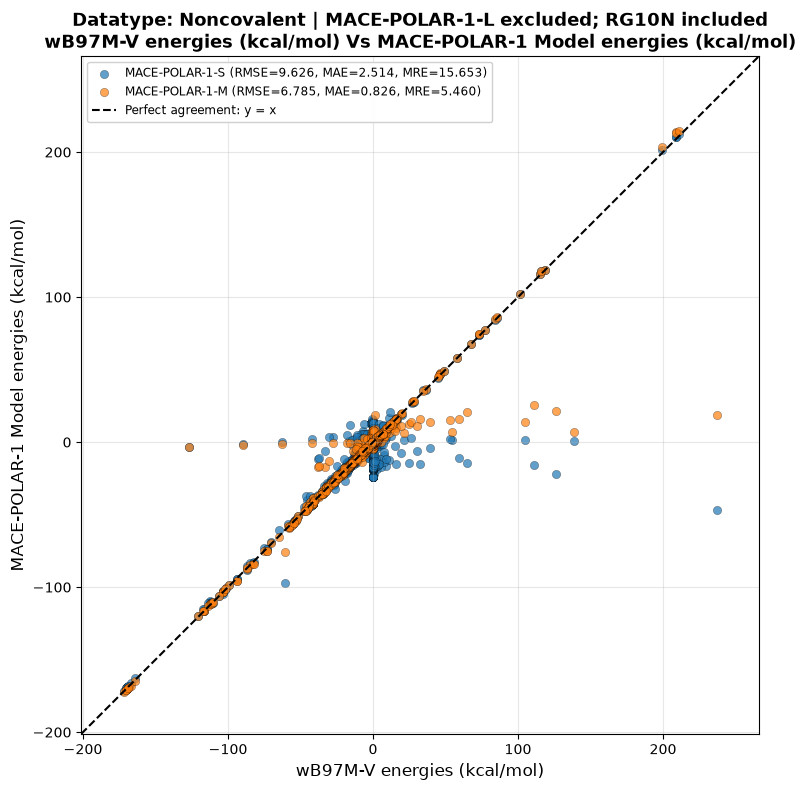

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Noncovalent_A_No_L_KEEP_RG10N_01_wB97M-V_vs_MACE_POLAR_BH_style.png


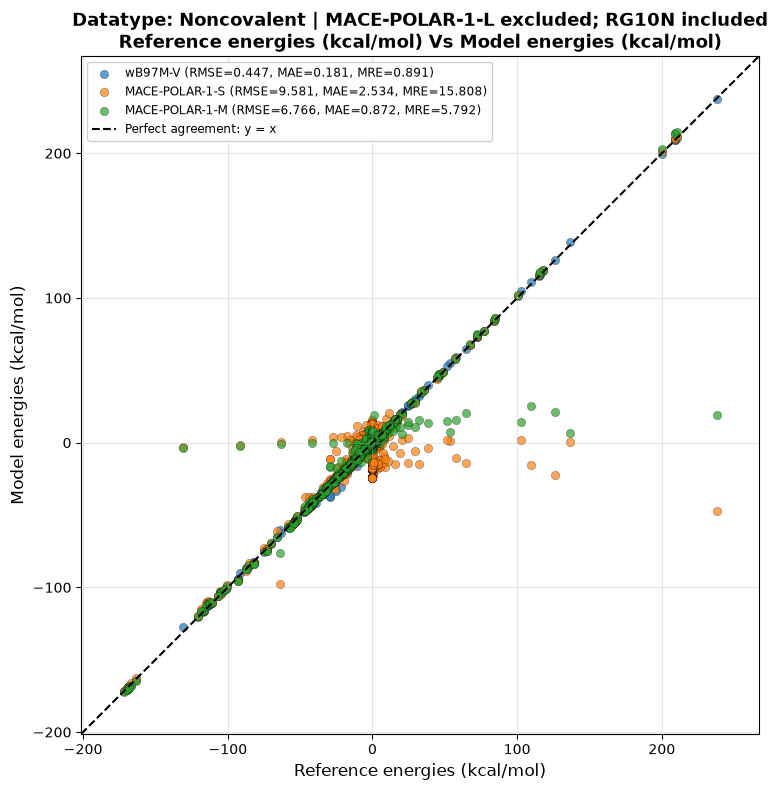

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Noncovalent_A_No_L_KEEP_RG10N_02_Reference_vs_All_Models_BH_style.png


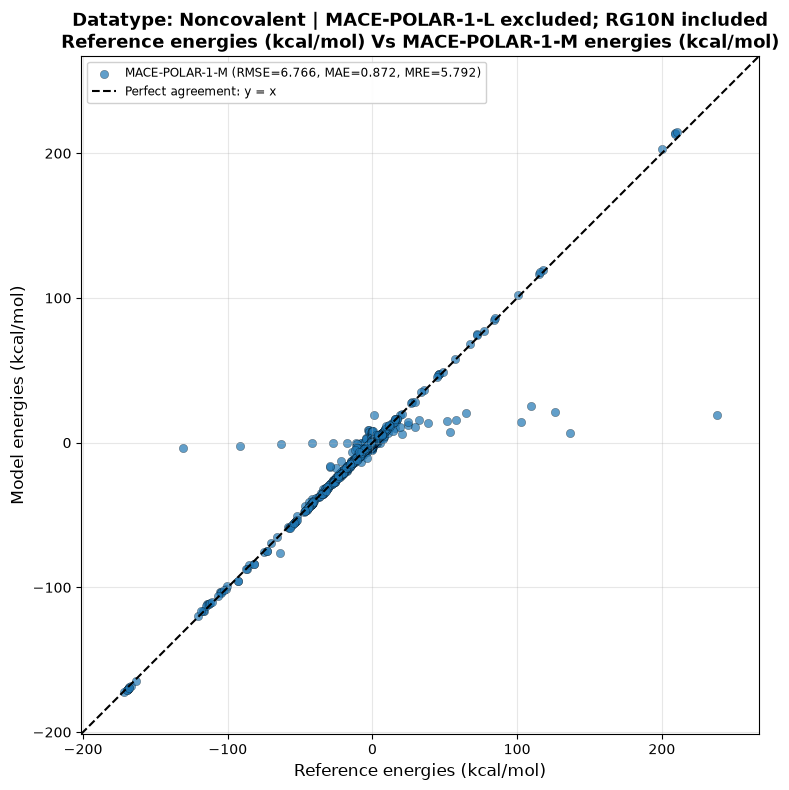

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Noncovalent_A_No_L_KEEP_RG10N_03_Reference_vs_mace-polar-1-m_BH_style.png


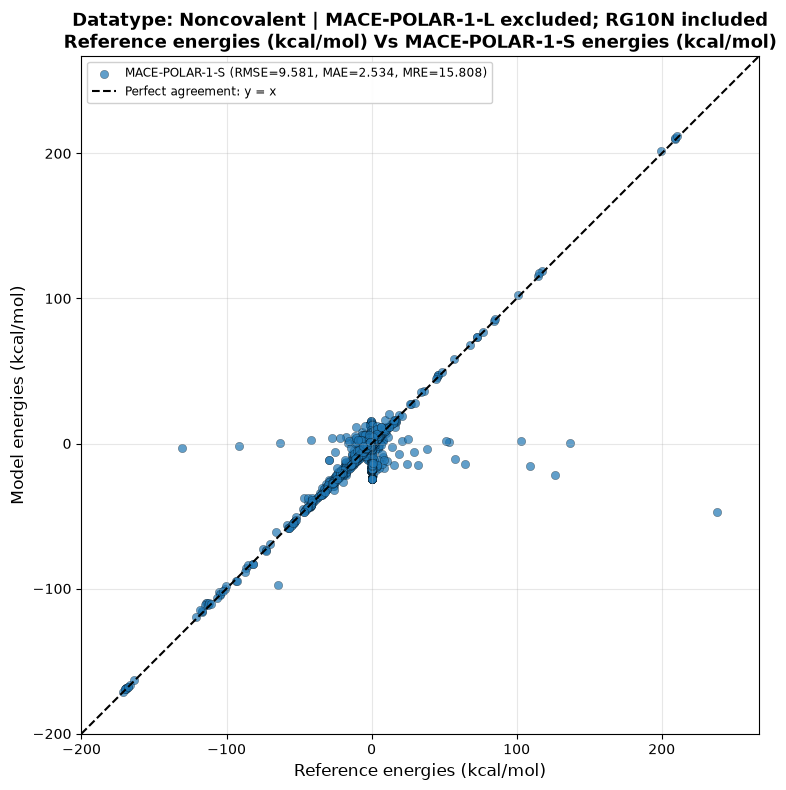

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Noncovalent_A_No_L_KEEP_RG10N_04_Reference_vs_mace-polar-1-s_BH_style.png


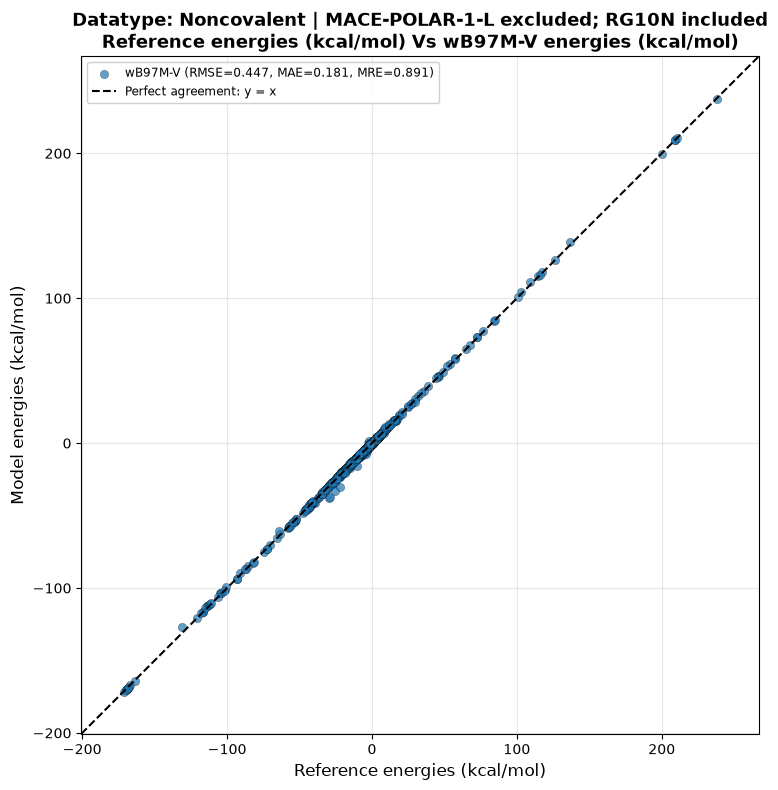

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Noncovalent_A_No_L_KEEP_RG10N_05_Reference_vs_wB97M-V_BH_style.png


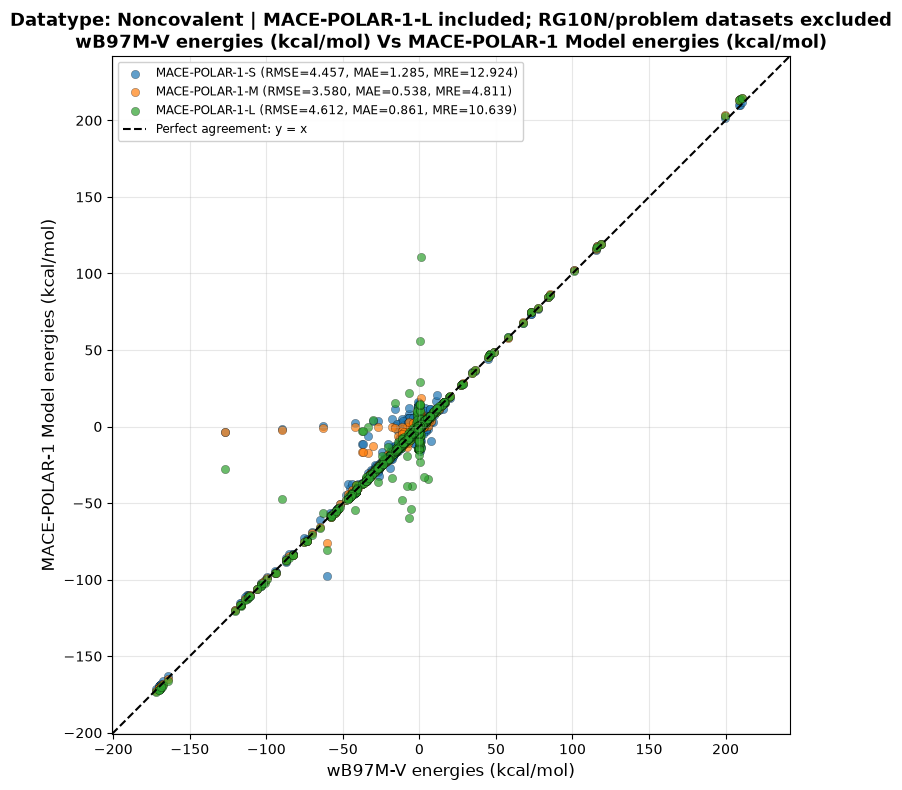

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Noncovalent_B_With_L_EXCLUDE_RG10N_BAD_01_wB97M-V_vs_MACE_POLAR_BH_style.png


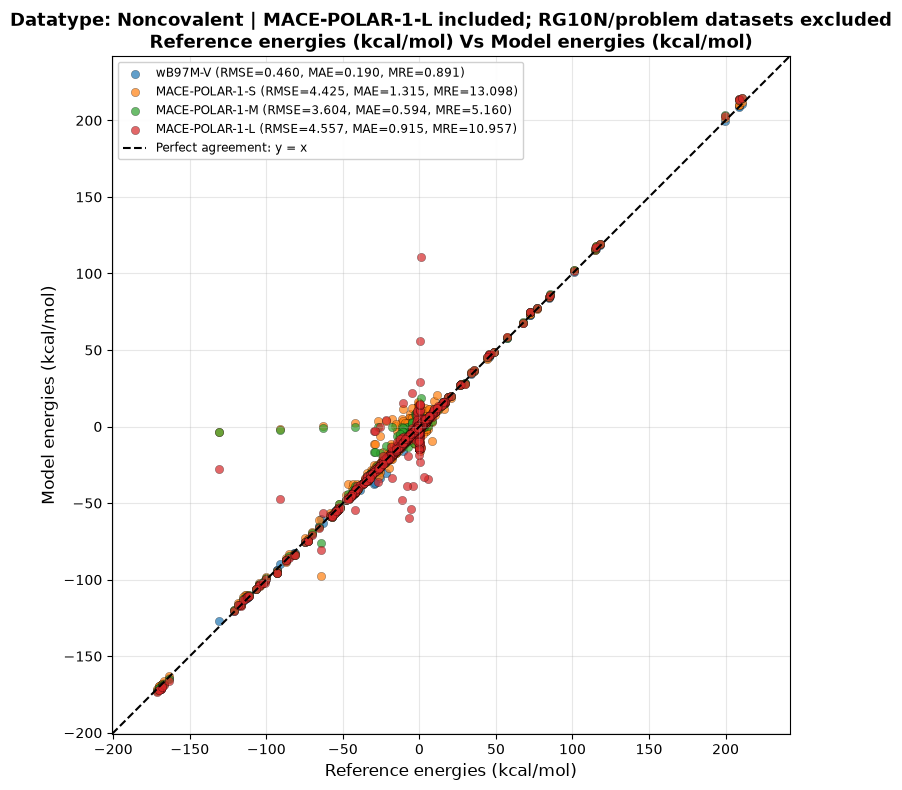

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Noncovalent_B_With_L_EXCLUDE_RG10N_BAD_02_Reference_vs_All_Models_BH_style.png


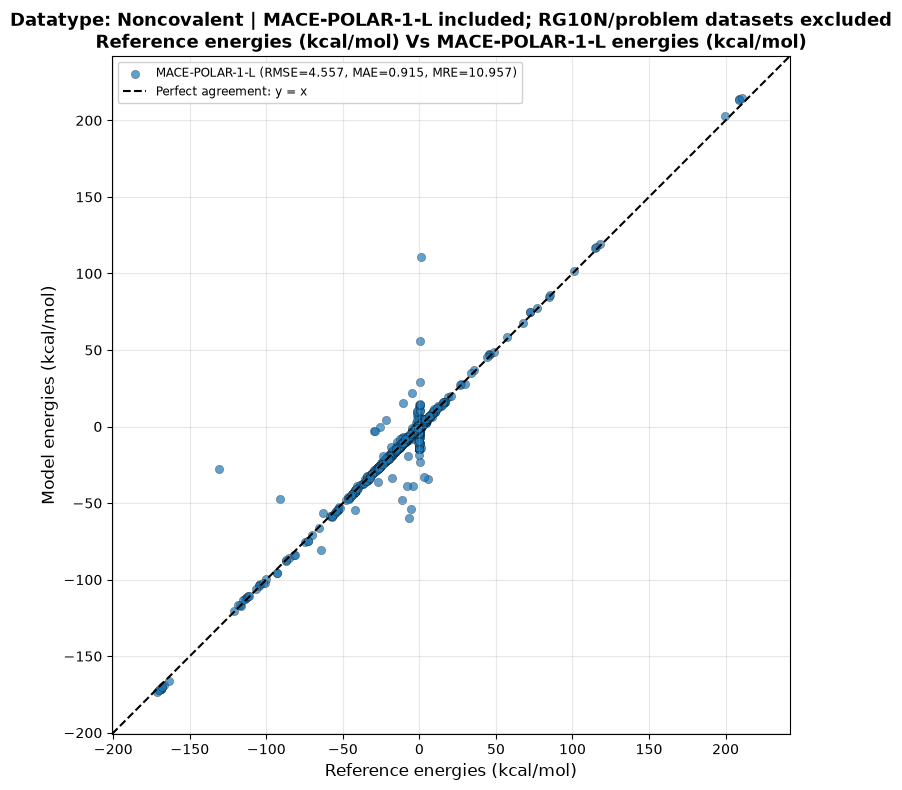

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Noncovalent_B_With_L_EXCLUDE_RG10N_BAD_03_Reference_vs_mace-polar-1-l_BH_style.png


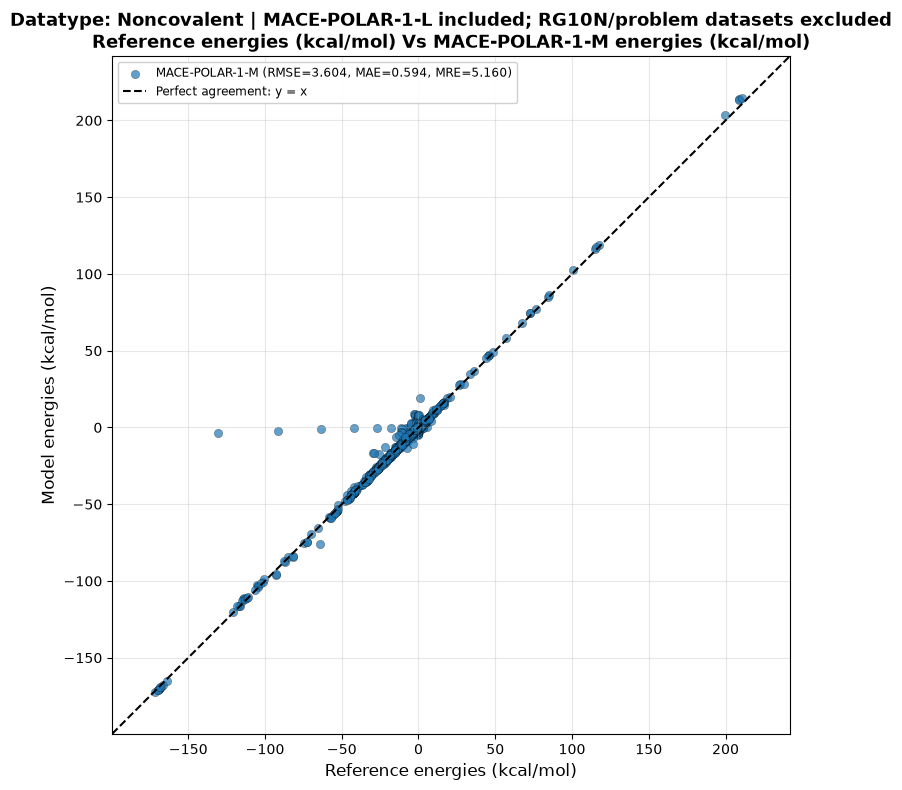

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Noncovalent_B_With_L_EXCLUDE_RG10N_BAD_04_Reference_vs_mace-polar-1-m_BH_style.png


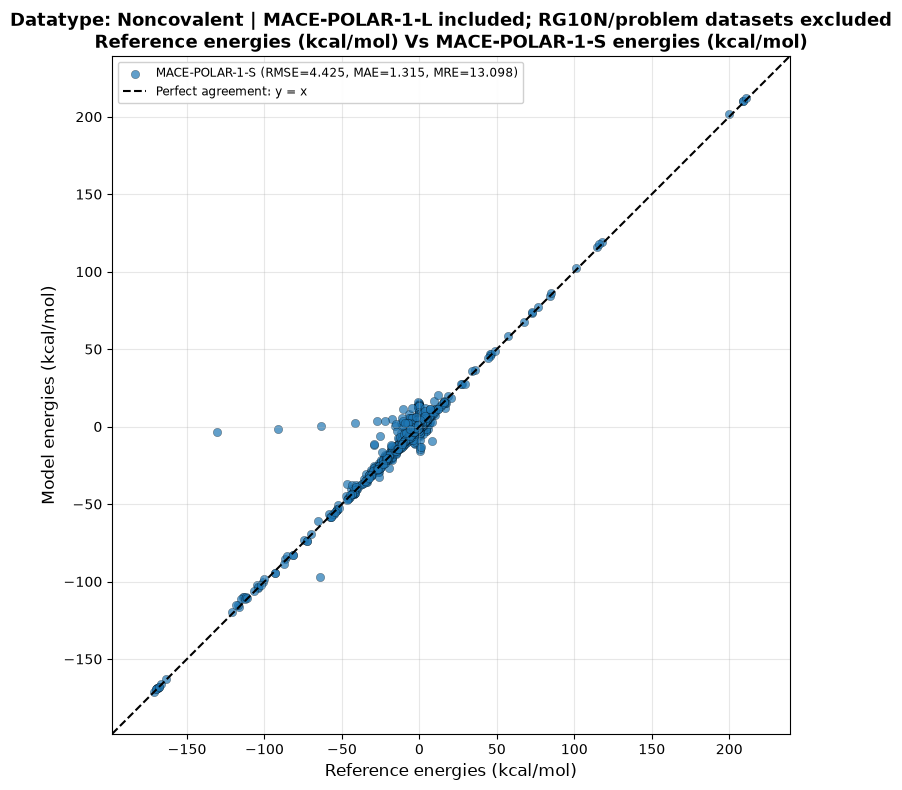

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Noncovalent_B_With_L_EXCLUDE_RG10N_BAD_05_Reference_vs_mace-polar-1-s_BH_style.png


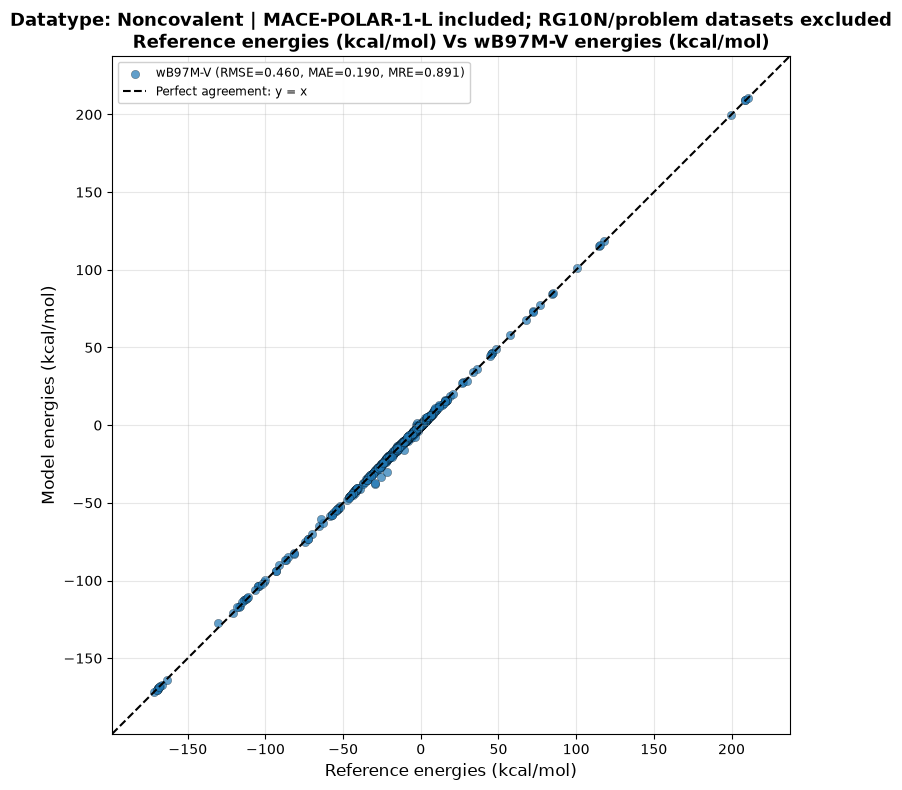

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Noncovalent_B_With_L_EXCLUDE_RG10N_BAD_06_Reference_vs_wB97M-V_BH_style.png

Saved plot metrics:
/home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Noncovalent_BH_style_two_corrected_plot_sets_metrics.csv

Plot metrics:
                                                                              Plot    X_axis         Y_axis          Model    N     RMSE      MAE  MRE_plotted_data  Full_Datatype_MRE  Pearson_r Excluded_from_plot
               Noncovalent_A_No_L_KEEP_RG10N_01_wB97M-V_vs_MACE_POLAR_BH_style.png   wB97M-V mace-polar-1-s MACE-POLAR-1-S 2942 9.625828 2.513979         15.653236          15.807882   0.884122                   
               Noncovalent_A_No_L_KEEP_RG10N_01_wB97M-V_vs_MACE_POLAR_BH_style.png   wB97M-V mace-polar-1-m MACE-POLAR-1-M 2942 6.785464 0.826279          5.460485           5.791844   0.943052                   
             Noncovalent_A_No_L_KEEP_RG10N_02_Reference_vs_Al

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATATYPE, UNIT = "Noncovalent", "kcal/mol"
TAG = DATATYPE.replace(" ", "_")

WEIGHTED = ["O24", "O24x4"]
ALL_MACE = ["mace-polar-1-s", "mace-polar-1-m", "mace-polar-1-l"]

LABELS = {
    "wB97M-V": "wB97M-V",
    "mace-polar-1-s": "MACE-POLAR-1-S",
    "mace-polar-1-m": "MACE-POLAR-1-M",
    "mace-polar-1-l": "MACE-POLAR-1-L",
}

BH_COLORS = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
BAD_ABS_ERROR_KCAL = 1000.0
BAD_MRE_NER = 1000.0
FORCE_EXCLUDE_WITH_L = ["RG10N"]

def find_root():
    p = Path.cwd().resolve()
    for q in [p] + list(p.parents):
        if all((q/x).exists() for x in ["Analysis", "Info"]):
            return q
    raise FileNotFoundError("Run from inside the GSCDB project folder.")

ROOT = find_root()
A, I = ROOT/"Analysis", ROOT/"Info"
FIG = A/"Figures"
FIG.mkdir(exist_ok=True)

df0 = pd.read_csv(A/f"Results_values_with_MACE_POLAR_Datatype_{TAG}_ALL3.csv", index_col=0)
summary = pd.read_csv(A/f"{TAG}_MACE_POLAR_ALL3_Datatype_Summary.csv")
per_set = pd.read_csv(A/f"{TAG}_MACE_POLAR_ALL3_per_set_metrics_long.csv")
std = pd.read_csv(I/"Standard_errors.csv", index_col=0)

def read_weights(path):
    w = pd.read_csv(path)
    if "Reaction" not in w.columns:
        w = pd.read_csv(path, index_col=0).reset_index().rename(columns={"index": "Reaction"})
    return w.set_index("Reaction")

weight_file = I/"DatasetEval_O24x5_weight.csv"
if not weight_file.exists():
    weight_file = ROOT/"DatasetEval_O24x5_weight.csv"

weights = read_weights(weight_file)

def metric_error(ds, e):
    e = pd.to_numeric(e, errors="coerce")
    if ds in WEIGHTED:
        w = weights.loc[e.index, "Weight"].astype(float)
        return float(np.sum(np.abs(e.to_numpy(float)) * w.to_numpy(float)))
    return float(np.mean(np.abs(e)))

def point_metrics(df, x, y):
    d = df[[x, y]].dropna()
    if len(d) == 0:
        return 0, np.nan, np.nan, np.nan
    xv, yv = d[x].to_numpy(float), d[y].to_numpy(float)
    e = yv - xv
    r = np.corrcoef(xv, yv)[0, 1] if len(xv) > 1 else np.nan
    return len(xv), float(np.sqrt(np.mean(e**2))), float(np.mean(np.abs(e))), float(r)

def mre_between(df, x, y):
    vals = []
    for ds, g in df.groupby("Dataset"):
        d = g[[x, y]].dropna()
        if ds not in std.index or len(d) != len(g):
            continue
        e = pd.to_numeric(d[y], errors="coerce") - pd.to_numeric(d[x], errors="coerce")
        vals.append(metric_error(ds, e) / float(std.loc[ds, "Metric"]))
    return float(np.mean(vals)) if vals else np.nan

def full_mre(model):
    return float(summary.loc[summary["Model"].eq(model), "Mean_Relative_Error_NER"].iloc[0])

def axis_limits(df, x, ys):
    arr = [pd.to_numeric(df[x], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna().to_numpy(float)]
    arr += [pd.to_numeric(df[y], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna().to_numpy(float) for y in ys]
    v = np.concatenate(arr)
    lo, hi = np.nanmin(v), np.nanmax(v)
    pad = 0.07 * (hi - lo) if hi > lo else 1.0
    return lo - pad, hi + pad

def detect_bad_datasets_for_L():
    bad = {ds: ["forced exclusion for MACE-POLAR-1-L plot set"] for ds in FORCE_EXCLUDE_WITH_L}

    for ds, g in df0.groupby("Dataset"):
        for m in ALL_MACE:
            if g[m].isna().any():
                bad.setdefault(ds, []).append(f"{m}: NaN values")

            emax = (
                pd.to_numeric(g[m], errors="coerce")
                - pd.to_numeric(g["Reference"], errors="coerce")
            ).abs().max()

            if pd.notna(emax) and emax > BAD_ABS_ERROR_KCAL:
                bad.setdefault(ds, []).append(f"{m}: max abs error = {emax:.2f} kcal/mol")

    high_mre = per_set[
        per_set["Model"].isin(ALL_MACE)
        & (pd.to_numeric(per_set["MRE_NER"], errors="coerce") > BAD_MRE_NER)
    ]

    for _, r in high_mre.iterrows():
        bad.setdefault(r["Dataset"], []).append(f"{r['Model']}: MRE/NER = {r['MRE_NER']:.2f}")

    return bad

BAD_REASONS = detect_bad_datasets_for_L()
EXCLUDE_WITH_L = sorted(BAD_REASONS)

print("Group A: MACE-POLAR-1-L excluded, RG10N included.")
print("Group B: MACE-POLAR-1-L included, excluded datasets:", EXCLUDE_WITH_L)

for ds, reason in BAD_REASONS.items():
    print(ds, "=>", "; ".join(reason))

def make_plot(df, x, ys, title, xlabel, ylabel, fname, against_x=False, excluded=""):
    lo, hi = axis_limits(df, x, ys)
    rows = []

    plt.figure(figsize=(10, 8))

    for i, y in enumerate(ys):
        n, rmse, mae, r = point_metrics(df, x, y)
        mre = mre_between(df, x, y) if against_x else mre_between(df, "Reference", y)

        plt.scatter(
            df[x],
            df[y],
            s=36,
            marker="o",
            color=BH_COLORS[i],
            alpha=0.70,
            edgecolors="black",
            linewidths=0.25,
            label=f"{LABELS[y]} (RMSE={rmse:.3f}, MAE={mae:.3f}, MRE={mre:.3f})",
        )

        rows.append({
            "Plot": fname,
            "X_axis": x,
            "Y_axis": y,
            "Model": LABELS[y],
            "N": n,
            "RMSE": rmse,
            "MAE": mae,
            "MRE_plotted_data": mre,
            "Full_Datatype_MRE": full_mre(y),
            "Pearson_r": r,
            "Excluded_from_plot": excluded,
        })

    plt.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.5, label="Perfect agreement: y = x")
    plt.xlim(lo, hi)
    plt.ylim(lo, hi)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=13, fontweight="bold")
    plt.grid(alpha=0.30)
    plt.legend(fontsize=8.5, framealpha=0.92)
    plt.tight_layout()

    path = FIG/fname
    plt.savefig(path, dpi=300)
    plt.show()
    print("Saved:", path)

    return rows

def plot_suite(df, prefix, mace_cols, all_cols, note, excluded):
    rows = []

    rows += make_plot(
        df,
        "wB97M-V",
        mace_cols,
        f"Datatype: Noncovalent | {note}\nwB97M-V energies (kcal/mol) Vs MACE-POLAR-1 Model energies (kcal/mol)",
        "wB97M-V energies (kcal/mol)",
        "MACE-POLAR-1 Model energies (kcal/mol)",
        f"{TAG}_{prefix}_01_wB97M-V_vs_MACE_POLAR_BH_style.png",
        against_x=True,
        excluded=excluded,
    )

    rows += make_plot(
        df,
        "Reference",
        all_cols,
        f"Datatype: Noncovalent | {note}\nReference energies (kcal/mol) Vs Model energies (kcal/mol)",
        "Reference energies (kcal/mol)",
        "Model energies (kcal/mol)",
        f"{TAG}_{prefix}_02_Reference_vs_All_Models_BH_style.png",
        excluded=excluded,
    )

    individual_models = [m for m in ["mace-polar-1-l", "mace-polar-1-m", "mace-polar-1-s"] if m in mace_cols]

    for i, model in enumerate(individual_models, start=3):
        rows += make_plot(
            df,
            "Reference",
            [model],
            f"Datatype: Noncovalent | {note}\nReference energies (kcal/mol) Vs {LABELS[model]} energies (kcal/mol)",
            "Reference energies (kcal/mol)",
            "Model energies (kcal/mol)",
            f"{TAG}_{prefix}_{i:02d}_Reference_vs_{model}_BH_style.png",
            excluded=excluded,
        )

    rows += make_plot(
        df,
        "Reference",
        ["wB97M-V"],
        f"Datatype: Noncovalent | {note}\nReference energies (kcal/mol) Vs wB97M-V energies (kcal/mol)",
        "Reference energies (kcal/mol)",
        "Model energies (kcal/mol)",
        f"{TAG}_{prefix}_{len(individual_models)+3:02d}_Reference_vs_wB97M-V_BH_style.png",
        excluded=excluded,
    )

    return rows

# ============================================================
# Group A: MACE-POLAR-1-L excluded, RG10N included
# ============================================================

df_A = df0.copy()

rows_A = plot_suite(
    df=df_A,
    prefix="A_No_L_KEEP_RG10N",
    mace_cols=["mace-polar-1-s", "mace-polar-1-m"],
    all_cols=["wB97M-V", "mace-polar-1-s", "mace-polar-1-m"],
    note="MACE-POLAR-1-L excluded; RG10N included",
    excluded="",
)

# ============================================================
# Group B: MACE-POLAR-1-L included, RG10N/problem datasets excluded
# ============================================================

df_B = df0[~df0["Dataset"].isin(EXCLUDE_WITH_L)].copy()

rows_B = plot_suite(
    df=df_B,
    prefix="B_With_L_EXCLUDE_RG10N_BAD",
    mace_cols=["mace-polar-1-s", "mace-polar-1-m", "mace-polar-1-l"],
    all_cols=["wB97M-V", "mace-polar-1-s", "mace-polar-1-m", "mace-polar-1-l"],
    note="MACE-POLAR-1-L included; RG10N/problem datasets excluded",
    excluded=",".join(EXCLUDE_WITH_L),
)

plot_metrics = pd.DataFrame(rows_A + rows_B)
plot_metrics_out = A/f"{TAG}_BH_style_two_corrected_plot_sets_metrics.csv"
plot_metrics.to_csv(plot_metrics_out, index=False)

print("\nSaved plot metrics:")
print(plot_metrics_out)
print("\nPlot metrics:")
print(plot_metrics.to_string(index=False))

# MACE-OMOL-0 models

In [ ]:
from pathlib import Path
import gc, numpy as np, pandas as pd
from tqdm import tqdm
from ase.io import read

try:
    from mace.calculators import mace_omol
except Exception:
    from mace.calculators.foundations_models import mace_omol

try:
    import torch
except Exception:
    torch = None

DATATYPE, UNIT = "Noncovalent", "kcal/mol"
TAG = DATATYPE.replace(" ", "_")
DEVICE = "cuda" if torch is not None and torch.cuda.is_available() else "cpu"
DTYPE, EV_TO_KCAL = "float64", 23.06054783
RECOMPUTE_ALL_MOLECULES, SAVE_EVERY = True, 50

MODELS = {
    "MACE-OMOL-0-100M": "extra_large",
    "MACE-OMOL-0-4M": (
        "https://github.com/ACEsuit/mace-foundations/releases/download/"
        "mace_omol_0/mace-omol-0-extra-large-4M.model"
    ),
}

EVAL_COLS = ["wB97M-V", *MODELS.keys()]
WEIGHTED = ["O24", "O24x4"]

def find_root():
    p = Path.cwd().resolve()
    for q in [p] + list(p.parents):
        if all((q/x).exists() for x in ["Analysis", "Info", "xyz_files", "qchem_inputs"]):
            return q
    raise FileNotFoundError("Run this notebook from inside the GSCDB project folder.")

ROOT = find_root()
A, I, X, Q = ROOT/"Analysis", ROOT/"Info", ROOT/"xyz_files", ROOT/"qchem_inputs"
(A/"Figures").mkdir(exist_ok=True)

out = {
    "mol": A/f"Molecule_Energies_MACE_OMOL0_Datatype_{TAG}.csv",
    "log": A/f"Molecule_Energies_MACE_OMOL0_Datatype_{TAG}_error_log.csv",
    "rxn": A/f"Reaction_Energies_with_MACE_OMOL0_Datatype_{TAG}.csv",
    "val": A/f"Results_values_with_MACE_OMOL0_Datatype_{TAG}.csv",
    "err": A/f"Results_errors_with_MACE_OMOL0_Datatype_{TAG}.csv",
    "mae": A/f"Errors_per_set_MAE_MACE_OMOL0_Datatype_{TAG}.csv",
    "rmse": A/f"Errors_per_set_RMSE_MACE_OMOL0_Datatype_{TAG}.csv",
    "metric": A/f"Errors_per_set_Metric_MACE_OMOL0_Datatype_{TAG}.csv",
    "mre": A/f"Errors_per_set_MRE_MACE_OMOL0_Datatype_{TAG}.csv",
    "rel": A/f"Relative_metric_per_set_MACE_OMOL0_Datatype_{TAG}.csv",
    "long": A/f"{TAG}_MACE_OMOL0_per_set_metrics_long.csv",
    "per_dataset": A/f"{TAG}_MACE_OMOL0_per_dataset_MAE_RMSE_MRE.csv",
    "summary": A/f"{TAG}_MACE_OMOL0_Datatype_Summary.csv",
}

def read_info(f):
    d = pd.read_csv(f)
    return d.set_index("Name") if "Name" in d.columns else pd.read_csv(f, index_col=0)

def read_weights(f):
    w = pd.read_csv(f)
    if "Reaction" not in w.columns:
        w = pd.read_csv(f, index_col=0).reset_index().rename(columns={"index": "Reaction"})
    return w.set_index("Reaction")

def qstate(f):
    ch, sp = 0, 1
    if not f.exists():
        return ch, sp
    lines = f.read_text(errors="ignore").splitlines()
    for i, line in enumerate(lines):
        if line.strip().lower() == "$molecule":
            for j in range(i + 1, len(lines)):
                p = lines[j].split()
                if len(p) >= 2:
                    try:
                        return int(float(p[0])), int(float(p[1]))
                    except Exception:
                        pass
    return ch, sp

def atoms_for(m):
    xyz = X/f"{m}.xyz"
    if not xyz.exists():
        raise FileNotFoundError(xyz)
    at = read(xyz)
    ch, sp = qstate(Q/f"{m}.in")
    ch = int(float(at.info.get("charge", ch)))
    sp = int(float(at.info.get("multiplicity", at.info.get("spin", sp))))
    at.info["charge"], at.info["spin"] = ch, sp
    return at, ch, sp

def reset(calc):
    for k, v in [("results", {}), ("atoms", None)]:
        try:
            setattr(calc, k, v)
        except Exception:
            pass
    try:
        calc.reset()
    except Exception:
        pass

def mols(st):
    return [x.strip() for x in str(st).split(",")][1::2]

def rxn_energy(st, mol_df, col):
    p, e = [x.strip() for x in str(st).split(",")], 0.0
    for i in range(0, len(p), 2):
        coef, mol = float(p[i]), p[i+1]
        if mol not in mol_df.index or pd.isna(mol_df.loc[mol, col]):
            return np.nan
        e += coef * float(mol_df.loc[mol, col])
    return e * EV_TO_KCAL

def metric_error(ds, e, weights):
    e = pd.to_numeric(e, errors="coerce")
    if ds in WEIGHTED:
        w = weights.loc[e.index, "Weight"].astype(float)
        return float(np.sum(np.abs(e.to_numpy(float)) * w.to_numpy(float)))
    return float(np.mean(np.abs(e)))

def pooled(x, y):
    d = pd.DataFrame({"x": x, "y": y}).dropna()
    if len(d) == 0:
        return 0, np.nan, np.nan, np.nan
    x, y = d.x.to_numpy(float), d.y.to_numpy(float)
    e = y - x
    r = np.corrcoef(x, y)[0, 1] if len(x) > 1 else np.nan
    return len(x), float(np.mean(np.abs(e))), float(np.sqrt(np.mean(e**2))), float(r)

print("ROOT:", ROOT)
print("DEVICE:", DEVICE)
print("DATATYPE:", DATATYPE)
print("MODELS:", list(MODELS))

df_eval = pd.read_csv(I/"DatasetEval.csv", index_col=0)
df_info = read_info(I/"Datasets.csv")
df_rxn0 = pd.read_csv(A/"Reaction_Energies.csv", index_col=0)
df_val0 = pd.read_csv(A/"Results_values.csv", index_col=0)
df_std = pd.read_csv(I/"Standard_errors.csv", index_col=0)

weight_file = I/"DatasetEval_O24x5_weight.csv"
if not weight_file.exists():
    weight_file = ROOT/"DatasetEval_O24x5_weight.csv"
weights = read_weights(weight_file)

if "wB97M-V" not in df_val0.columns:
    raise ValueError("Missing required column in Results_values.csv: wB97M-V")

datasets = df_info.index[df_info["Datatype"].astype(str).eq(DATATYPE)].tolist()
ev = df_eval[df_eval["Dataset"].isin(datasets)].copy()
rxn0, val0 = df_rxn0.loc[ev.index].copy(), df_val0.loc[ev.index].copy()
all_mols = sorted({m for st in ev["Stoichiometry"] for m in mols(st)})

for ds in WEIGHTED:
    data_rows = set(ev.index[ev["Dataset"].eq(ds)])
    weight_rows = set(weights.index[weights["Dataset"].eq(ds)])
    if data_rows != weight_rows:
        raise ValueError(f"{ds}: weight rows do not match DatasetEval rows.")

print("Datasets:", datasets)
print("Number of datasets:", len(datasets))
print("Number of data points:", len(ev))
print("Unique molecules:", len(all_mols))

mol_df = pd.DataFrame(index=all_mols) if RECOMPUTE_ALL_MOLECULES or not out["mol"].exists() else pd.read_csv(out["mol"], index_col=0)
mol_df.index.name = "Molecule"

for c in ["charge", "spin", "num_atoms", *MODELS.keys()]:
    if c not in mol_df.columns:
        mol_df[c] = np.nan

for m in all_mols:
    if m not in mol_df.index:
        mol_df.loc[m, :] = np.nan
    if pd.isna(mol_df.loc[m, "num_atoms"]):
        at, ch, sp = atoms_for(m)
        mol_df.loc[m, ["charge", "spin", "num_atoms"]] = [ch, sp, len(at)]

errors = []

for col, model in MODELS.items():
    print(f"\nRunning {col}")
    calc = mace_omol(model=model, device=DEVICE, default_dtype=DTYPE)

    for n, m in enumerate(tqdm(all_mols, desc=col), 1):
        if not RECOMPUTE_ALL_MOLECULES and pd.notna(mol_df.loc[m, col]):
            continue
        try:
            at, ch, sp = atoms_for(m)
            reset(calc)
            at.calc = calc
            mol_df.loc[m, ["charge", "spin", "num_atoms", col]] = [ch, sp, len(at), float(at.get_potential_energy())]
        except Exception as exc:
            mol_df.loc[m, col] = np.nan
            errors.append({"Molecule": m, "Model": col, "Error": repr(exc)})
        if n % SAVE_EVERY == 0:
            mol_df.to_csv(out["mol"])

    mol_df.to_csv(out["mol"])
    del calc
    gc.collect()
    if torch is not None and torch.cuda.is_available():
        torch.cuda.empty_cache()

pd.DataFrame(errors).to_csv(out["log"], index=False)
mol_df.to_csv(out["mol"])

rxn = rxn0.copy()
for rid, row in tqdm(ev.iterrows(), total=len(ev), desc="Reaction energies"):
    for col in MODELS:
        rxn.loc[rid, col] = rxn_energy(row["Stoichiometry"], mol_df, col)
rxn.to_csv(out["rxn"])

val = val0.copy()
for col in MODELS:
    val[col] = rxn[col]
val.to_csv(out["val"])

err = val.copy()
for col in [c for c in val.columns if c not in ["Dataset", "Reaction", "Reference"]]:
    err[col] = pd.to_numeric(val[col], errors="coerce") - pd.to_numeric(val["Reference"], errors="coerce")
err.to_csv(out["err"])

mae_rows, rmse_rows, metric_rows, mre_rows, long = [], [], [], [], []

for ds, g in err.groupby("Dataset"):
    denom = float(df_std.loc[ds, "Metric"])
    mae_r, rmse_r, metric_r, mre_r = [{"Dataset": ds, "Datatype": DATATYPE} for _ in range(4)]

    for col in EVAL_COLS:
        e = pd.to_numeric(g[col], errors="coerce")
        ok = bool(e.notna().all())
        mae = float(np.mean(np.abs(e))) if ok else np.nan
        rmse = float(np.sqrt(np.mean(e**2))) if ok else np.nan
        met = metric_error(ds, e, weights) if ok else np.nan
        mre = met / denom if ok else np.nan
        status = "COMPLETE" if ok else "INCOMPLETE"

        mae_r[col], rmse_r[col], metric_r[col], mre_r[col] = mae, rmse, met, mre
        long.append({
            "Dataset": ds, "Datatype": DATATYPE, "Model": col, "Unit": UNIT,
            "N_total": len(e), "N_used": int(e.notna().sum()), "Status": status,
            "MAE": mae, "RMSE": rmse, "Metric_Error": met,
            "Standard_Error_Metric": denom, "MRE_NER": mre,
        })

    mae_rows.append(mae_r)
    rmse_rows.append(rmse_r)
    metric_rows.append(metric_r)
    mre_rows.append(mre_r)

pd.DataFrame(mae_rows).set_index("Dataset").sort_index().to_csv(out["mae"])
pd.DataFrame(rmse_rows).set_index("Dataset").sort_index().to_csv(out["rmse"])
pd.DataFrame(metric_rows).set_index("Dataset").sort_index().to_csv(out["metric"])
pd.DataFrame(mre_rows).set_index("Dataset").sort_index().to_csv(out["mre"])
pd.DataFrame(mre_rows).set_index("Dataset").sort_index().to_csv(out["rel"])

long_df = pd.DataFrame(long)
long_df.to_csv(out["long"], index=False)
long_df.to_csv(out["per_dataset"], index=False)

summary = []

for col in EVAL_COLS:
    n, pmae, prmse, r = pooled(val["Reference"], val[col])
    sub = long_df[long_df["Model"].eq(col)]
    summary.append({
        "Datatype": DATATYPE,
        "Model": col,
        "Unit": UNIT,
        "N_points": n,
        "N_datasets_total": len(sub),
        "N_datasets_complete": int(sub["Status"].eq("COMPLETE").sum()),
        "N_datasets_incomplete": int(sub["Status"].eq("INCOMPLETE").sum()),
        "Pooled_MAE": pmae,
        "Pooled_RMSE": prmse,
        "Pearson_r": r,
        "Mean_Set_MAE": float(sub["MAE"].mean(skipna=True)),
        "Mean_Set_RMSE": float(sub["RMSE"].mean(skipna=True)),
        "Mean_Relative_Error_NER": float(sub["MRE_NER"].mean(skipna=True)),
    })

summary_df = pd.DataFrame(summary)
summary_df.to_csv(out["summary"], index=False)

print("\nMolecule-energy NaNs:")
print(mol_df[list(MODELS)].isna().sum())

print("\nReaction-value NaNs:")
print(val[list(MODELS)].isna().sum())

print("\nDatatype summary:")
print(summary_df.to_string(index=False))

print("\nRG10N check:")
print(
    long_df[long_df["Dataset"].eq("RG10N")]
    [["Dataset", "Model", "Status", "N_used", "N_total", "MAE", "RMSE", "MRE_NER"]]
    .to_string(index=False)
)

print("\nWeighted datasets check:")
print(
    long_df[long_df["Dataset"].isin(WEIGHTED)]
    [["Dataset", "Model", "MAE", "RMSE", "Metric_Error", "MRE_NER"]]
    .to_string(index=False)
)

print("\nSaved files:")
for f in out.values():
    print(f)

/home/campus.ncl.ac.uk/c5062080/MScProject/.venv/lib/python3.13/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
ROOT: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB
DEVICE: cuda
DATATYPE: Noncovalent
MODELS: ['MACE-OMOL-0-100M', 'MACE-OMOL-0-4M']
Datasets: ['3B-69', '3BHET', 'A19Rel6', 'A24', 'ADIM6', 'AHB21', 'Bauza30', 'BzDC215', 'CARBHB8', 'CHB6', 'CT20', 'DS14', 'FmH2O10', 'H2O16Rel4', 'H2O20Rel9', 'HB262', 'HB49', 'HCP32', 'He3', 'HEAVY28', 'HSG', 'HW30', 'HW6Cl5', 'HW6F', 'IHB100', 'IHB100x2', 'IL16', 'NBC10', 'NC11', 'O24', 'O24x4', 'PNICO23', 'RG10N', 'RG18', 'S22', 'S66', 'S66Rel7', 'Shields38', 'SW49Bind22', 'SW49Rel28', 'TA13', 'WATER27', 'X40', 'X40x5', 'XB25']
Number of datasets: 45
Number of data points: 2942
Unique molecules: 5711

Running MACE-OMOL-0-100M
Using float64 for MACECalculator, recommended for geometry optimization.


/home/campus.ncl.ac.uk/c5062080/MScProject/.venv/lib/python3.13/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
MACE-OMOL-0-100M:  13%|█▎        | 746/5711 [01:17<07:18, 11.31it/s]

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATATYPE, UNIT = "Noncovalent", "kcal/mol"
TAG = DATATYPE.replace(" ", "_")

OMOL = ["MACE-OMOL-0-100M", "MACE-OMOL-0-4M"]
MODELS_ALL = ["wB97M-V", *OMOL]
WEIGHTED = ["O24", "O24x4"]

LABELS = {
    "wB97M-V": "wB97M-V",
    "MACE-OMOL-0-100M": "MACE-OMOL-0-100M",
    "MACE-OMOL-0-4M": "MACE-OMOL-0-4M",
}

BH_COLORS = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
EXCLUDE_DATASETS_FROM_PLOTS = []

def find_root():
    p = Path.cwd().resolve()
    for q in [p] + list(p.parents):
        if all((q/x).exists() for x in ["Analysis", "Info"]):
            return q
    raise FileNotFoundError("Run this notebook from inside the GSCDB project folder.")

ROOT = find_root()
A, I = ROOT/"Analysis", ROOT/"Info"
FIG = A/"Figures"
FIG.mkdir(exist_ok=True)

df0 = pd.read_csv(A/f"Results_values_with_MACE_OMOL0_Datatype_{TAG}.csv", index_col=0)
summary = pd.read_csv(A/f"{TAG}_MACE_OMOL0_Datatype_Summary.csv")
std = pd.read_csv(I/"Standard_errors.csv", index_col=0)

weight_file = I/"DatasetEval_O24x5_weight.csv"
if not weight_file.exists():
    weight_file = ROOT/"DatasetEval_O24x5_weight.csv"

weights = pd.read_csv(weight_file)
if "Reaction" not in weights.columns:
    weights = pd.read_csv(weight_file, index_col=0).reset_index().rename(columns={"index": "Reaction"})
weights = weights.set_index("Reaction")

for c in MODELS_ALL:
    if c not in df0.columns:
        raise ValueError(f"Missing column in results file: {c}")

df = df0[~df0["Dataset"].isin(EXCLUDE_DATASETS_FROM_PLOTS)].copy()

print("Datatype:", DATATYPE)
print("Models:", OMOL)
print("Full points:", len(df0))
print("Plotted points:", len(df))
print("Datasets plotted:", df["Dataset"].nunique())
print("Excluded from plots only:", EXCLUDE_DATASETS_FROM_PLOTS)

def metric_error(ds, e):
    e = pd.to_numeric(e, errors="coerce")
    if ds in WEIGHTED:
        w = weights.loc[e.index, "Weight"].astype(float)
        return float(np.sum(np.abs(e.to_numpy(float)) * w.to_numpy(float)))
    return float(np.mean(np.abs(e)))

def point_metrics(df, x, y):
    d = df[[x, y]].dropna()
    if len(d) == 0:
        return 0, np.nan, np.nan, np.nan
    xv, yv = d[x].to_numpy(float), d[y].to_numpy(float)
    e = yv - xv
    r = np.corrcoef(xv, yv)[0, 1] if len(xv) > 1 else np.nan
    return len(xv), float(np.sqrt(np.mean(e**2))), float(np.mean(np.abs(e))), float(r)

def mre_between(df, x, y):
    vals = []
    for ds, g in df.groupby("Dataset"):
        d = g[[x, y]].dropna()
        if ds not in std.index or len(d) != len(g):
            continue
        e = pd.to_numeric(d[y], errors="coerce") - pd.to_numeric(d[x], errors="coerce")
        vals.append(metric_error(ds, e) / float(std.loc[ds, "Metric"]))
    return float(np.mean(vals)) if vals else np.nan

def full_mre(model):
    return float(summary.loc[summary["Model"].eq(model), "Mean_Relative_Error_NER"].iloc[0])

def axis_limits(df, x, ys):
    arr = [pd.to_numeric(df[x], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna().to_numpy(float)]
    arr += [pd.to_numeric(df[y], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna().to_numpy(float) for y in ys]
    v = np.concatenate(arr)
    lo, hi = np.nanmin(v), np.nanmax(v)
    pad = 0.07 * (hi - lo) if hi > lo else 1.0
    return lo - pad, hi + pad

def make_plot(x, ys, title, xlabel, ylabel, fname, against_x=False):
    lo, hi = axis_limits(df, x, ys)
    rows = []

    plt.figure(figsize=(10, 8))

    for i, y in enumerate(ys):
        n, rmse, mae, r = point_metrics(df, x, y)
        mre = mre_between(df, x, y) if against_x else mre_between(df, "Reference", y)

        plt.scatter(
            df[x],
            df[y],
            s=36,
            marker="o",
            color=BH_COLORS[i],
            alpha=0.70,
            edgecolors="black",
            linewidths=0.25,
            label=f"{LABELS[y]} (RMSE={rmse:.3f}, MAE={mae:.3f}, MRE={mre:.3f})",
        )

        rows.append({
            "Plot": fname,
            "X_axis": x,
            "Y_axis": y,
            "Model": LABELS[y],
            "N": n,
            "RMSE": rmse,
            "MAE": mae,
            "MRE_plotted_data": mre,
            "Full_Datatype_MRE": full_mre(y),
            "Pearson_r": r,
            "Excluded_from_plot": ",".join(EXCLUDE_DATASETS_FROM_PLOTS),
        })

    plt.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.5, label="Perfect agreement: y = x")
    plt.xlim(lo, hi)
    plt.ylim(lo, hi)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=13, fontweight="bold")
    plt.grid(alpha=0.30)
    plt.legend(fontsize=8.5, framealpha=0.92)
    plt.tight_layout()

    path = FIG/fname
    plt.savefig(path, dpi=300)
    plt.show()
    print("Saved:", path)

    return rows

rows = []

rows += make_plot(
    "wB97M-V",
    OMOL,
    "Datatype: Noncovalent\nwB97M-V energies (kcal/mol) Vs MACE-OMOL-0 Model energies (kcal/mol)",
    "wB97M-V energies (kcal/mol)",
    "MACE-OMOL-0 Model energies (kcal/mol)",
    f"{TAG}_MACE_OMOL0_01_wB97M-V_vs_MACE_OMOL0_BH_style.png",
    against_x=True,
)

rows += make_plot(
    "Reference",
    MODELS_ALL,
    "Datatype: Noncovalent\nReference energies (kcal/mol) Vs Model energies (kcal/mol)",
    "Reference energies (kcal/mol)",
    "Model energies (kcal/mol)",
    f"{TAG}_MACE_OMOL0_02_Reference_vs_All_Models_BH_style.png",
)

for i, model in enumerate(OMOL, start=3):
    rows += make_plot(
        "Reference",
        [model],
        f"Datatype: Noncovalent\nReference energies (kcal/mol) Vs {LABELS[model]} energies (kcal/mol)",
        "Reference energies (kcal/mol)",
        "Model energies (kcal/mol)",
        f"{TAG}_MACE_OMOL0_{i:02d}_Reference_vs_{model}_BH_style.png",
    )

rows += make_plot(
    "Reference",
    ["wB97M-V"],
    "Datatype: Noncovalent\nReference energies (kcal/mol) Vs wB97M-V energies (kcal/mol)",
    "Reference energies (kcal/mol)",
    "Model energies (kcal/mol)",
    f"{TAG}_MACE_OMOL0_{len(OMOL)+3:02d}_Reference_vs_wB97M-V_BH_style.png",
)

plot_metrics = pd.DataFrame(rows)
plot_metrics_out = A/f"{TAG}_MACE_OMOL0_BH_style_correlation_plot_metrics.csv"
plot_metrics.to_csv(plot_metrics_out, index=False)

print("\nSaved plot metrics:")
print(plot_metrics_out)
print("\nPlot metrics:")
print(plot_metrics.to_string(index=False))